# NYC Yellow Taxi Trip Analysis

## Project Overview

This project aims to perform an end-to-end data science workflow on the NYC Yellow Taxi Trip dataset. The analysis includes data understanding, data cleaning, exploratory data analysis (EDA), feature engineering, preprocessing, machine learning modeling, and model evaluation.

The dataset used in this project is publicly provided by the **New York City Taxi and Limousine Commission (TLC)**.

> **Dataset Scope:** Only the **January 2026** Yellow Taxi Trip Records are used in this project. This subset contains millions of real-world taxi trips and is sufficient for comprehensive analysis while remaining computationally manageable on a local machine.

> Data source : https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
import os

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

### Load the dataset

In [2]:
df = pd.read_parquet('data/yellow_tripdata_2026-01.parquet')
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.20,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.90,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.70,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.70,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.50,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3724884,2,2026-01-31 23:26:00,2026-01-31 23:39:16,NaN,1.62,NaN,None,237,161,0,17.09,0.00,0.5,0.00,0.0,1.0,21.84,NaN,NaN,0.75
3724885,2,2026-01-31 23:33:53,2026-01-31 23:34:07,NaN,0.00,NaN,None,42,42,0,23.19,0.00,0.5,0.00,0.0,1.0,24.69,NaN,NaN,0.00
3724886,2,2026-01-31 23:40:23,2026-01-31 23:56:10,NaN,6.84,NaN,None,137,69,0,29.21,0.00,0.5,0.00,0.0,1.0,33.96,NaN,NaN,0.75
3724887,2,2026-01-31 23:10:21,2026-01-31 23:20:00,NaN,1.53,NaN,None,137,162,0,19.19,0.00,0.5,0.00,0.0,1.0,23.94,NaN,NaN,0.75


In [3]:
taxi_zone_lookup = pd.read_csv('data/taxi_zone_lookup.csv')
taxi_zone_lookup

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone
...,...,...,...,...
260,261,Manhattan,World Trade Center,Yellow Zone
261,262,Manhattan,Yorkville East,Yellow Zone
262,263,Manhattan,Yorkville West,Yellow Zone
263,264,Unknown,NaN,NaN


## Chapter 1 : Data Overview

In [4]:
file_path = "data/yellow_tripdata_2026-01.parquet"

trip_duration = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

overview_df = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Total Features",
        "Pickup Date Range",
        "Total Observation Days",
        "Dataset Size (MB)",
        "Exact Duplicate Records",
        "Total Missing Cells",
        "Rows With Missing Values",
        "Negative Fare Records",
        "Non-positive Duration Records",
    ],
    "Value": [
        f"{len(df):,}",
        df.shape[1],
        f"{df['tpep_pickup_datetime'].min():%Y-%m-%d} to "
        f"{df['tpep_pickup_datetime'].max():%Y-%m-%d}",
        df["tpep_pickup_datetime"].dt.date.nunique(),
        round(os.path.getsize(file_path) / (1024 ** 2), 2),
        f"{df.duplicated().sum():,}",
        f"{df.isna().sum().sum():,}",
        f"{df.isna().any(axis=1).sum():,}",
        f"{(df['fare_amount'] < 0).sum():,}",
        f"{(trip_duration <= 0).sum():,}",
    ],
})

display(overview_df)

,Metric,Value
0,Total Records,"3,724,889"
1,Total Features,20
2,Pickup Date Range,2025-12-31 to 2026-02-01
3,Total Observation Days,33
4,Dataset Size (MB),61.19
5,Exact Duplicate Records,0
6,Total Missing Cells,"5,440,290"
7,Rows With Missing Values,"1,088,058"
8,Negative Fare Records,"39,463"
9,Non-positive Duration Records,"45,070"


## Chapter 2 : Data Quality Check

In [5]:
missing_summary = (
    df.isna()
      .sum()
      .to_frame("missing_count")
      .assign(missing_pct=lambda data: (data["missing_count"] / len(df) * 100).round(2))
      .query("missing_count > 0")
      .sort_values("missing_count", ascending=False)
)

display(missing_summary)

,missing_count,missing_pct
passenger_count,1088058,29.21
RatecodeID,1088058,29.21
store_and_fwd_flag,1088058,29.21
congestion_surcharge,1088058,29.21
Airport_fee,1088058,29.21


In [6]:
df_clean = df.copy()

df_clean["trip_duration_min"] = (
    df_clean["tpep_dropoff_datetime"] - df_clean["tpep_pickup_datetime"]
).dt.total_seconds() / 60

df_clean = df_clean[
    (df_clean["trip_duration_min"] > 0) &
    (df_clean["fare_amount"] >= 0) &
    (df_clean["total_amount"] >= 0)
].copy()

print(f"Before cleaning: {len(df):,}")
print(f"After cleaning:  {len(df_clean):,}")
print(f"Rows removed:    {len(df) - len(df_clean):,}")

Before cleaning: 3,724,889
After cleaning:  3,639,817
Rows removed:    85,072


### Feature Engineering

In [7]:
pickup_datetime = df_clean["tpep_pickup_datetime"]

# Time-based features
# Keep trip_duration_min from the cleaning step because it is useful for EDA and ML.
df_clean["pickup_date"] = pickup_datetime.dt.date
df_clean["pickup_hour"] = pickup_datetime.dt.hour
df_clean["pickup_dayofweek"] = pickup_datetime.dt.dayofweek
df_clean["pickup_day_name"] = pickup_datetime.dt.day_name()
df_clean["is_weekend"] = (df_clean["pickup_dayofweek"] >= 5).astype(int)
df_clean["pickup_period"] = pd.cut(
    df_clean["pickup_hour"],
    bins=[-1, 5, 10, 15, 19, 23],
    labels=["Late Night", "Morning", "Afternoon", "Evening", "Night"]
)
df_clean["is_rush_hour"] = df_clean["pickup_hour"].isin([7, 8, 9, 16, 17, 18, 19]).astype(int)
df_clean["is_night"] = df_clean["pickup_hour"].isin([0, 1, 2, 3, 4, 5]).astype(int)

# EDA features
df_clean["speed_mph"] = np.where(
    df_clean["trip_duration_min"] > 0,
    df_clean["trip_distance"] / (df_clean["trip_duration_min"] / 60),
    np.nan
)
df_clean["tip_percentage"] = np.where(
    df_clean["fare_amount"] > 0,
    df_clean["tip_amount"] / df_clean["fare_amount"] * 100,
    np.nan
)
df_clean["fare_per_mile"] = np.where(
    df_clean["trip_distance"] > 0,
    df_clean["fare_amount"] / df_clean["trip_distance"],
    np.nan
)
df_clean["distance_category"] = pd.cut(
    df_clean["trip_distance"],
    bins=[-0.01, 1, 3, 7, 15, np.inf],
    labels=["Very Short", "Short", "Medium", "Long", "Very Long"]
)

df_clean["route_id"] = (
    df_clean["PULocationID"].astype(str)
    + " -> "
    + df_clean["DOLocationID"].astype(str)
)

df_clean.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,trip_duration_min,pickup_date,pickup_hour,pickup_dayofweek,pickup_day_name,is_weekend,pickup_period,is_rush_hour,is_night,speed_mph,tip_percentage,fare_per_mile,distance_category,route_id
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00,5.550000,2026-01-01,0,3,Thursday,0,Late Night,0,1,10.486486,50.833333,7.422680,Very Short,239 -> 238
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75,5.716667,2026-01-01,0,3,Thursday,0,Late Night,0,1,9.446064,0.000000,8.777778,Very Short,163 -> 162
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75,8.883333,2026-01-01,0,3,Thursday,0,Late Night,0,1,9.455910,23.364486,7.642857,Short,43 -> 237
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75,42.800000,2026-01-01,0,3,Thursday,0,Late Night,0,1,7.822430,28.708010,6.935484,Medium,142 -> 209
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75,13.500000,2026-01-01,0,3,Thursday,0,Late Night,0,1,9.600000,28.518519,6.250000,Short,88 -> 144


In [8]:
pickup_zones = taxi_zone_lookup.rename(columns={
    "LocationID": "PULocationID",
    "Borough": "pickup_borough",
    "Zone": "pickup_zone",
    "service_zone": "pickup_service_zone"
})[["PULocationID", "pickup_borough", "pickup_zone", "pickup_service_zone"]]

dropoff_zones = taxi_zone_lookup.rename(columns={
    "LocationID": "DOLocationID",
    "Borough": "dropoff_borough",
    "Zone": "dropoff_zone",
    "service_zone": "dropoff_service_zone"
})[["DOLocationID", "dropoff_borough", "dropoff_zone", "dropoff_service_zone"]]

df_enriched = (
    df_clean
    .merge(pickup_zones, on="PULocationID", how="left", validate="many_to_one")
    .merge(dropoff_zones, on="DOLocationID", how="left", validate="many_to_one")
)

zone_label_cols = [
    "pickup_borough", "pickup_zone", "pickup_service_zone",
    "dropoff_borough", "dropoff_zone", "dropoff_service_zone"
]
df_enriched[zone_label_cols] = df_enriched[zone_label_cols].fillna("Unknown")

df_enriched["borough_route"] = (
    df_enriched["pickup_borough"]
    + " -> "
    + df_enriched["dropoff_borough"]
)
df_enriched["zone_route"] = (
    df_enriched["pickup_zone"]
    + " -> "
    + df_enriched["dropoff_zone"]
)
df_enriched["is_interborough_trip"] = (
    df_enriched["pickup_borough"] != df_enriched["dropoff_borough"]
).astype(int)

print(f"Rows before join: {len(df_clean):,}")
print(f"Rows after join:  {len(df_enriched):,}")
print()
print("Unknown pickup zones:", (df_enriched["pickup_zone"] == "Unknown").sum())
print("Unknown drop-off zones:", (df_enriched["dropoff_zone"] == "Unknown").sum())

df_enriched[[
    "PULocationID", "pickup_borough", "pickup_zone", "pickup_service_zone",
    "DOLocationID", "dropoff_borough", "dropoff_zone", "dropoff_service_zone",
    "borough_route", "zone_route", "is_interborough_trip"
]].head()

Rows before join: 3,639,817
Rows after join:  3,639,817

Unknown pickup zones: 4302
Unknown drop-off zones: 5665


,PULocationID,pickup_borough,pickup_zone,pickup_service_zone,DOLocationID,dropoff_borough,dropoff_zone,dropoff_service_zone,borough_route,zone_route,is_interborough_trip
0,239,Manhattan,Upper West Side South,Yellow Zone,238,Manhattan,Upper West Side North,Yellow Zone,Manhattan -> Manhattan,Upper West Side South -> Upper West Side North,0
1,163,Manhattan,Midtown North,Yellow Zone,162,Manhattan,Midtown East,Yellow Zone,Manhattan -> Manhattan,Midtown North -> Midtown East,0
2,43,Manhattan,Central Park,Yellow Zone,237,Manhattan,Upper East Side South,Yellow Zone,Manhattan -> Manhattan,Central Park -> Upper East Side South,0
3,142,Manhattan,Lincoln Square East,Yellow Zone,209,Manhattan,Seaport,Yellow Zone,Manhattan -> Manhattan,Lincoln Square East -> Seaport,0
4,88,Manhattan,Financial District South,Yellow Zone,144,Manhattan,Little Italy/NoLiTa,Yellow Zone,Manhattan -> Manhattan,Financial District South -> Little Italy/NoLiTa,0


In [9]:
eda_check = pd.DataFrame({
    "Metric": [
        "Cleaned Records",
        "Enriched Records",
        "Unique Pickup Zones",
        "Unique Dropoff Zones",
        "Unknown Pickup Zones",
        "Unknown Dropoff Zones",
        "Interborough Trips",
    ],
    "Value": [
        f"{len(df_clean):,}",
        f"{len(df_enriched):,}",
        df_enriched["pickup_zone"].nunique(),
        df_enriched["dropoff_zone"].nunique(),
        f"{(df_enriched['pickup_zone'] == 'Unknown').sum():,}",
        f"{(df_enriched['dropoff_zone'] == 'Unknown').sum():,}",
        f"{df_enriched['is_interborough_trip'].sum():,}",
    ]
})

eda_check

,Metric,Value
0,Cleaned Records,"3,639,817"
1,Enriched Records,"3,639,817"
2,Unique Pickup Zones,261
3,Unique Dropoff Zones,259
4,Unknown Pickup Zones,"4,302"
5,Unknown Dropoff Zones,"5,665"
6,Interborough Trips,"551,624"


In [10]:
def outlier_summary(data, numerical_cols) :

    results = []

    for col in numerical_cols :
        series = data[col].dropna()
        q1 = series.quantile(.25)
        q3 = series.quantile(.75)

        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outlier = (
            (series < lower) |
            (series > upper)
        ).sum()

        results.append({
            "column" : col,
            "count" : len(series),
            "mean" : round(series.mean(), 2),
            "median" : round(series.median(), 2),
            "min" : round(series.min(), 2),
            "max" : round(series.max(), 2),
            "iqr_lower_bound": round(lower,2),
            "iqr_upper_bound": round(upper,2),
            "outlier_count": outlier,
            "outlier_pct": round(outlier/len(series)*100,2)
        })

    return (
        pd.DataFrame(results).sort_values("outlier_pct", ascending=False)
    )

numerical_cols = [
    "passenger_count",
    "trip_distance",
    "trip_duration_min",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "speed_mph",
    "tip_percentage",
    "fare_per_mile"
]

fee_cols = [
    "extra",
    "mta_tax",
    "tolls_amount",
    "improvement_surcharge",
    "congestion_surcharge",
    "Airport_fee",
    "cbd_congestion_fee"
]

df_outlier = outlier_summary(df_enriched, numerical_cols)
fee_outlier = outlier_summary(df_enriched, fee_cols)

In [11]:
df_outlier

,column,count,mean,median,min,max,iqr_lower_bound,iqr_upper_bound,outlier_count,outlier_pct
0,passenger_count,2551839,1.26,1.00,0.00,9.00,1.00,1.00,468723,18.37
1,trip_distance,3639817,6.53,1.82,0.00,269097.48,-3.12,7.88,409047,11.24
5,total_amount,3639817,29.88,23.22,0.00,2560.20,-7.88,59.12,307084,8.44
6,speed_mph,3639817,24.38,9.25,0.00,2218899.96,-2.52,22.19,258362,7.10
3,fare_amount,3639817,21.35,15.60,0.00,2555.20,-14.30,50.50,242930,6.67
8,fare_per_mile,3518153,27.48,7.54,0.00,49000.00,-0.61,16.27,212485,6.04
2,trip_duration_min,3639817,17.42,13.53,0.02,7507.90,-11.32,40.95,205155,5.64
4,tip_amount,3639817,2.63,2.00,0.00,766.00,-5.60,9.32,199527,5.48
7,tip_percentage,3638289,16.00,15.00,0.00,300000.00,-42.50,70.83,9410,0.26


In [12]:
fee_outlier

,column,count,mean,median,min,max,iqr_lower_bound,iqr_upper_bound,outlier_count,outlier_pct
4,congestion_surcharge,2551839,2.21,2.50,0.00,2.50,2.50,2.50,291423,11.42
5,Airport_fee,2551839,0.15,0.00,0.00,1.75,0.00,0.00,225769,8.85
2,tolls_amount,3639817,0.51,0.00,0.00,122.22,0.00,0.00,235378,6.47
3,improvement_surcharge,3639817,0.97,1.00,0.00,1.00,1.00,1.00,115363,3.17
1,mta_tax,3639817,0.49,0.50,0.00,4.75,0.50,0.50,46036,1.26
0,extra,3639817,1.06,0.00,-0.75,17.46,-3.75,6.25,35824,0.98
6,cbd_congestion_fee,3639817,0.53,0.75,0.00,0.75,-1.12,1.88,0,0.00


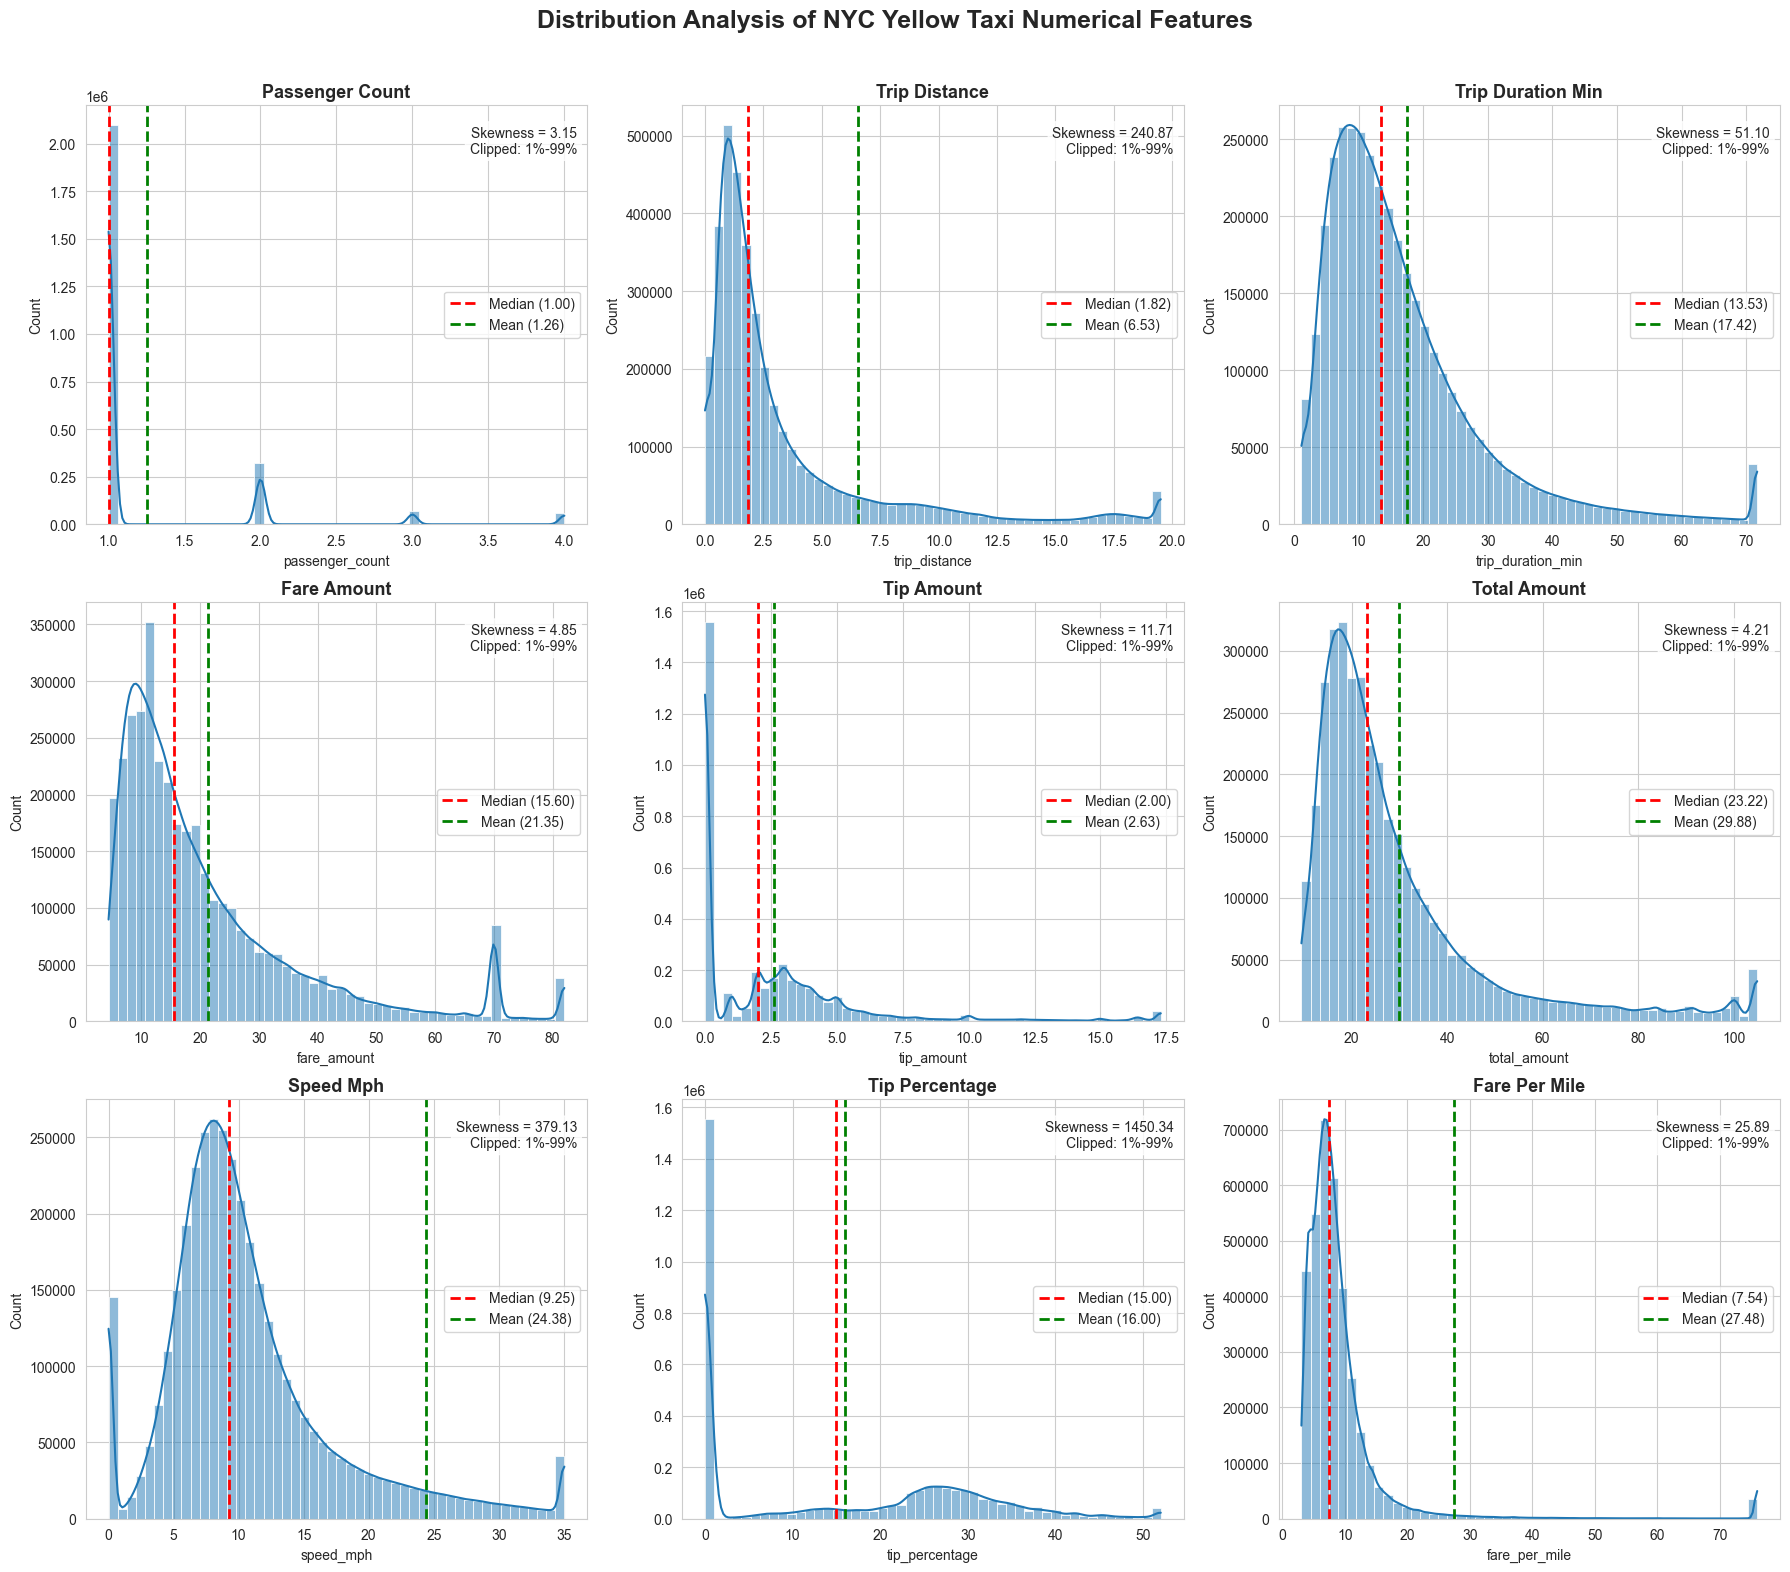

In [13]:
target_cols = [
    "passenger_count",
    "trip_distance",
    "trip_duration_min",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "speed_mph",
    "tip_percentage",
    "fare_per_mile"
]

fig, axes = plt.subplots(3, 3, figsize=(18, 16))
axes = axes.flatten()

for ax, col in zip(axes, target_cols):

    series = df_enriched[col].dropna()

    lower = series.quantile(0.01)
    upper = series.quantile(0.99)
    clipped_series = series.clip(lower, upper)

    mean_val = series.mean()
    median_val = series.median()
    skew_val = series.skew()

    sns.histplot(
        clipped_series,
        bins=50,
        kde=True,
        ax=ax
    )

    ax.axvline(
        median_val,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Median ({median_val:.2f})"
    )

    ax.axvline(
        mean_val,
        color="green",
        linestyle="--",
        linewidth=2,
        label=f"Mean ({mean_val:.2f})"
    )

    ax.set_title(
        f'{col.replace("_", " ").title()}',
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel(col)
    ax.set_ylabel("Count")

    ax.text(
        0.98,
        0.95,
        f"Skewness = {skew_val:.2f}\nClipped: 1%-99%",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.8
        )
    )

    ax.legend()

fig.suptitle(
    "Distribution Analysis of NYC Yellow Taxi Numerical Features",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
fig.subplots_adjust(top=0.92)

os.makedirs("img", exist_ok=True)

filepath = os.path.join(
    "img",
    "distribution_analysis_nyc_yellow_taxi_numerical_features.png"
)

plt.savefig(
    filepath,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

### Insight: Distribution Analysis of NYC Yellow Taxi Numerical Features

Most numerical features show a **positively skewed (right-skewed)** distribution, where the mean is higher than the median. This indicates that most trips are short and relatively low-cost, while a smaller number of long, expensive, or unusual trips create a long right tail.

`passenger_count` is strongly concentrated around **1 passenger**, showing that most yellow taxi trips are individual rides. Although there are trips with 2-4 passengers, they occur much less frequently than solo trips.

`trip_distance` and `trip_duration_min` also show right-skewed patterns. Most trips are short in both distance and duration, but some longer trips increase the average values. This is why the mean is noticeably higher than the median for both features.

Fare-related variables such as `fare_amount`, `total_amount`, and `fare_per_mile` are also right-skewed. Most trips have moderate fares, while a smaller number of trips have much higher costs, likely due to longer routes, airport trips, tolls, surcharges, or very short trips with fixed charges.

`tip_amount` and `tip_percentage` show uneven tipping behavior. Many trips have low or zero tips, while some trips have relatively high tip values, creating a long-tailed distribution.

`speed_mph` and `fare_per_mile` have very high skewness values, suggesting the presence of extreme or unusual records. These features should be treated carefully in later analysis or machine learning, especially because they can be affected by very short distances or durations.

Overall, NYC yellow taxi trips are dominated by short, regular, low-to-moderate fare rides. However, the dataset also contains meaningful outliers, so extreme values should be analyzed separately rather than removed blindly.

## Chapter 3 : Exploration Data Analysis (EDA)

In [14]:
df_eda = df_enriched.copy()
df_eda.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,trip_duration_min,pickup_date,pickup_hour,pickup_dayofweek,pickup_day_name,is_weekend,pickup_period,is_rush_hour,is_night,speed_mph,tip_percentage,fare_per_mile,distance_category,route_id,pickup_borough,pickup_zone,pickup_service_zone,dropoff_borough,dropoff_zone,dropoff_service_zone,borough_route,zone_route,is_interborough_trip
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00,5.550000,2026-01-01,0,3,Thursday,0,Late Night,0,1,10.486486,50.833333,7.422680,Very Short,239 -> 238,Manhattan,Upper West Side South,Yellow Zone,Manhattan,Upper West Side North,Yellow Zone,Manhattan -> Manhattan,Upper West Side South -> Upper West Side North,0
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75,5.716667,2026-01-01,0,3,Thursday,0,Late Night,0,1,9.446064,0.000000,8.777778,Very Short,163 -> 162,Manhattan,Midtown North,Yellow Zone,Manhattan,Midtown East,Yellow Zone,Manhattan -> Manhattan,Midtown North -> Midtown East,0
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75,8.883333,2026-01-01,0,3,Thursday,0,Late Night,0,1,9.455910,23.364486,7.642857,Short,43 -> 237,Manhattan,Central Park,Yellow Zone,Manhattan,Upper East Side South,Yellow Zone,Manhattan -> Manhattan,Central Park -> Upper East Side South,0
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75,42.800000,2026-01-01,0,3,Thursday,0,Late Night,0,1,7.822430,28.708010,6.935484,Medium,142 -> 209,Manhattan,Lincoln Square East,Yellow Zone,Manhattan,Seaport,Yellow Zone,Manhattan -> Manhattan,Lincoln Square East -> Seaport,0
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75,13.500000,2026-01-01,0,3,Thursday,0,Late Night,0,1,9.600000,28.518519,6.250000,Short,88 -> 144,Manhattan,Financial District South,Yellow Zone,Manhattan,Little Italy/NoLiTa,Yellow Zone,Manhattan -> Manhattan,Financial District South -> Little Italy/NoLiTa,0


In [15]:
df_eda['pickup_day_name'].unique()

array(['Thursday', 'Wednesday', 'Friday', 'Saturday', 'Sunday', 'Monday',
       'Tuesday'], dtype=object)

### 3.1 When Do Yellow Taxi Trips Happen Most Often?

In [16]:
hourly_trips = (
    df_eda
    .groupby("pickup_hour")
    .size()
    .reset_index(name="trip_count")
)
hourly_trips

,pickup_hour,trip_count
0,0,109643
1,1,76302
2,2,53064
3,3,37936
4,4,28134
5,5,32258
6,6,62528
7,7,111304
8,8,145242
9,9,153269


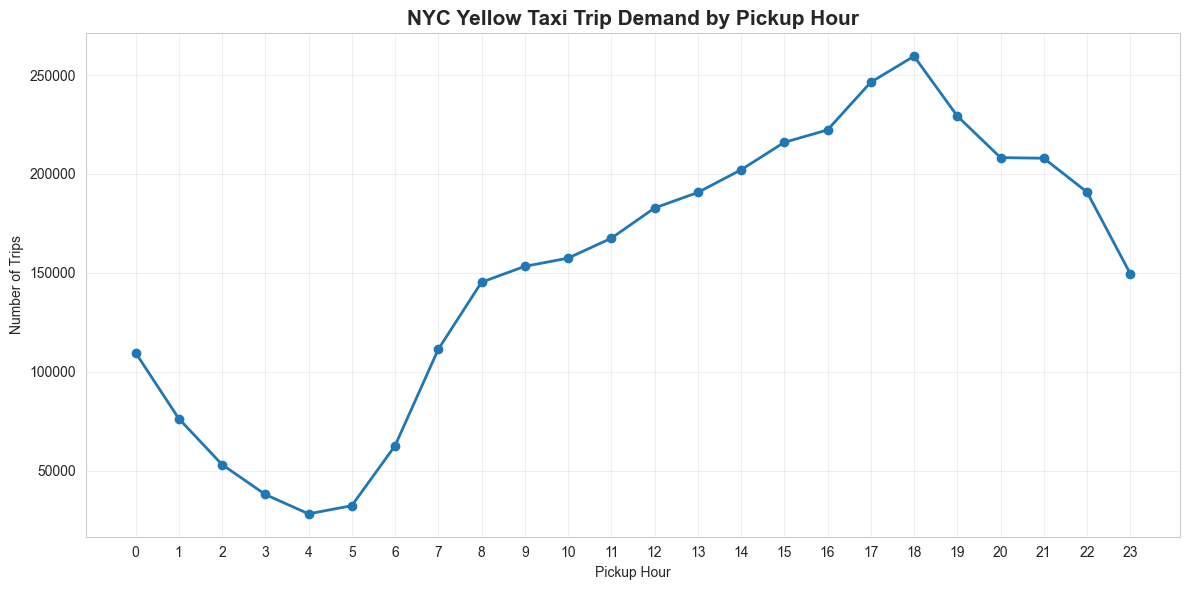

In [17]:
plt.figure(figsize=(12, 6))

plt.plot(
    hourly_trips["pickup_hour"],
    hourly_trips["trip_count"],
    marker="o",
    linewidth=2,
    color="#1f77b4"
)

plt.title(
    "NYC Yellow Taxi Trip Demand by Pickup Hour",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Pickup Hour")
plt.ylabel("Number of Trips")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)

plt.tight_layout()

filepath = os.path.join('img', 'NYC_Yellow_Taxi_Trip_Demand_by_Pickup_Hour.png')
plt.savefig(filepath, dpi=300, bbox_inches="tight", facecolor='white')
plt.show()

### Insight: Trip Demand by Pickup Hour

Yellow taxi demand is lowest during the early morning hours, especially around **4 AM**, which likely reflects reduced travel activity after midnight and before the start of the workday.

Trip volume begins to rise sharply from **6 AM to 8 AM**, showing the start of morning mobility activity. After that, demand continues increasing steadily throughout the day.

The highest demand occurs around **6 PM**, indicating a strong evening peak. This pattern likely reflects commute activity, after-work travel, dining, shopping, and other evening movements across the city.

After the evening peak, demand gradually declines from **7 PM onward**, but it remains relatively high until around **10 PM**, suggesting that taxi usage continues strongly into the evening before dropping late at night.

Overall, NYC yellow taxi demand follows a clear daily pattern: low activity before dawn, steady growth during the day, and a major peak during the evening rush period.

### 3.2 Which Days Have the Highest Yellow Taxi Demand?

In [18]:
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

df_eda["pickup_day_name"] = pd.Categorical(
    df_eda["pickup_day_name"],
    categories=day_order,
    ordered=True
)

daily_trips = (
    df_eda
    .groupby("pickup_day_name", observed=False)
    .size()
    .reset_index(name="trip_count")
    .sort_values("pickup_day_name")
)
daily_trips

,pickup_day_name,trip_count
0,Monday,370470
1,Tuesday,472410
2,Wednesday,493964
3,Thursday,640466
4,Friday,640521
5,Saturday,657037
6,Sunday,364949


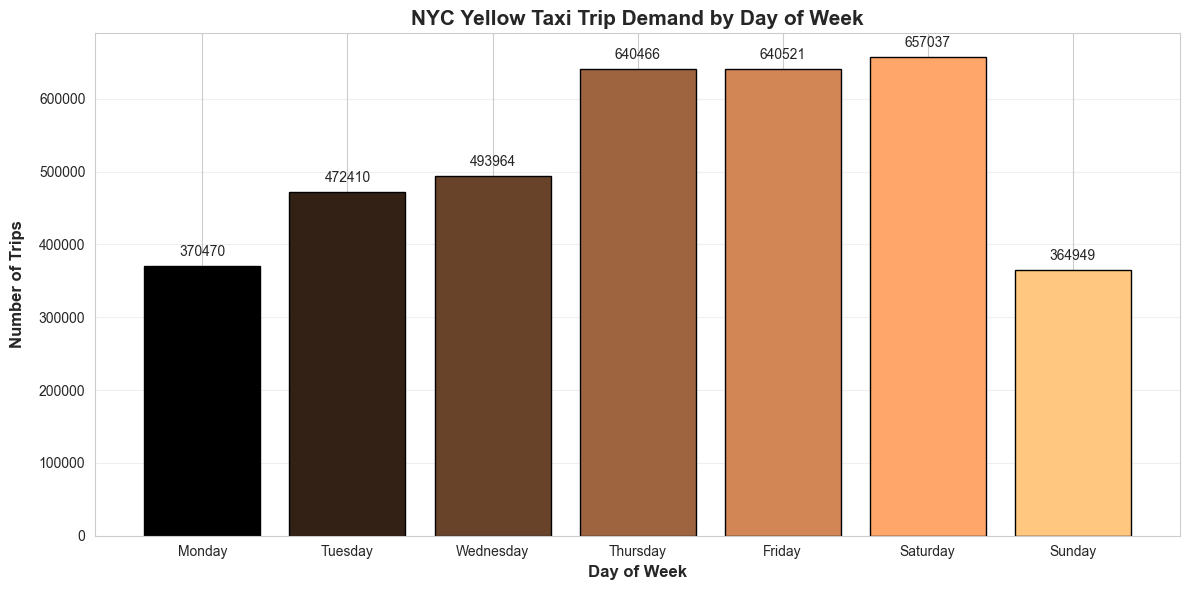

In [19]:
plt.figure(figsize=(12, 6))

colors = plt.cm.copper(np.linspace(0,1, len(daily_trips)))

bar = plt.bar(
    daily_trips["pickup_day_name"],
    daily_trips["trip_count"],
    color=colors,
    edgecolor="black"
)

plt.bar_label(bar, fmt='%.0f', padding=5)

plt.title(
    "NYC Yellow Taxi Trip Demand by Day of Week",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Day of Week", fontweight='bold', fontsize=12)
plt.ylabel("Number of Trips", fontweight='bold',fontsize=12, labelpad=10)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

filepath = os.path.join("img", "NYC_Yellow_Taxi_Trip_Demand_by_Day_of_Week.png")
plt.savefig(filepath, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

### Insight: Trip Demand by Day of Week

Yellow taxi demand varies clearly across the week. The number of trips is lowest on **Sunday** and **Monday**, while demand increases steadily from Tuesday to Saturday.

The highest trip volume occurs on **Saturday**, followed closely by **Friday** and **Thursday**. This suggests that taxi usage is especially strong toward the end of the week, likely driven by commuting, nightlife, leisure travel, shopping, and weekend-related activities.

Weekday demand is not evenly distributed. Monday has relatively low trip volume compared to Thursday and Friday, indicating that taxi activity becomes stronger as the workweek progresses.

Overall, the pattern shows that NYC yellow taxi demand is strongest from **Thursday to Saturday**, while early-week and Sunday demand are lower. This suggests that both workweek activity and weekend mobility play an important role in taxi demand.

### 3.3 When Are the Busiest Taxi Demand Periods During the Week?

In [20]:
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

hour_day_trips = (
    df_eda
    .groupby(["pickup_day_name", "pickup_hour"], observed=False)
    .size()
    .reset_index(name="trip_count")
)

hour_day_pivot = (
    hour_day_trips
    .pivot(
        index="pickup_day_name",
        columns="pickup_hour",
        values="trip_count"
    )
    .reindex(day_order)
)

hour_day_pivot

pickup_hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
pickup_day_name,,,,,,,,,,,,,,,,,,,,,,,,
Monday,7619,3775,2313,1704,2008,3600,7274,12853,17325,17674,17700,18632,20358,20923,23459,24678,25099,26834,27424,22434,20373,19663,15154,11594
Tuesday,6619,3149,1873,1313,1853,4486,10006,19727,25587,24879,22818,22976,23720,23389,26437,28735,29436,34865,35789,29897,29692,29944,22452,12768
Wednesday,6961,3471,1833,1344,1807,4102,10339,20676,26716,25344,23152,22938,24086,25244,27100,29474,30018,35596,38013,32737,31014,31771,25357,14871
Thursday,17026,13752,9936,8027,5968,6794,12617,22616,28059,27678,26586,27604,30202,30552,33707,36672,37223,43037,45388,39503,38171,40109,34443,24796
Friday,14862,8196,5047,3385,3417,6088,11871,21033,25803,26362,26632,28657,30814,32625,35880,38483,39534,43493,47322,43618,36550,36431,38534,35884
Saturday,30933,24446,17499,12026,7420,4205,6068,8483,13655,19685,25301,29258,33706,37018,34403,37346,39607,41092,43901,42535,35896,34531,40034,37989
Sunday,25623,19513,14563,10137,5661,2983,4353,5916,8097,11647,15213,17405,19855,20860,21070,20574,21307,21430,21670,18556,16544,15478,14844,11650


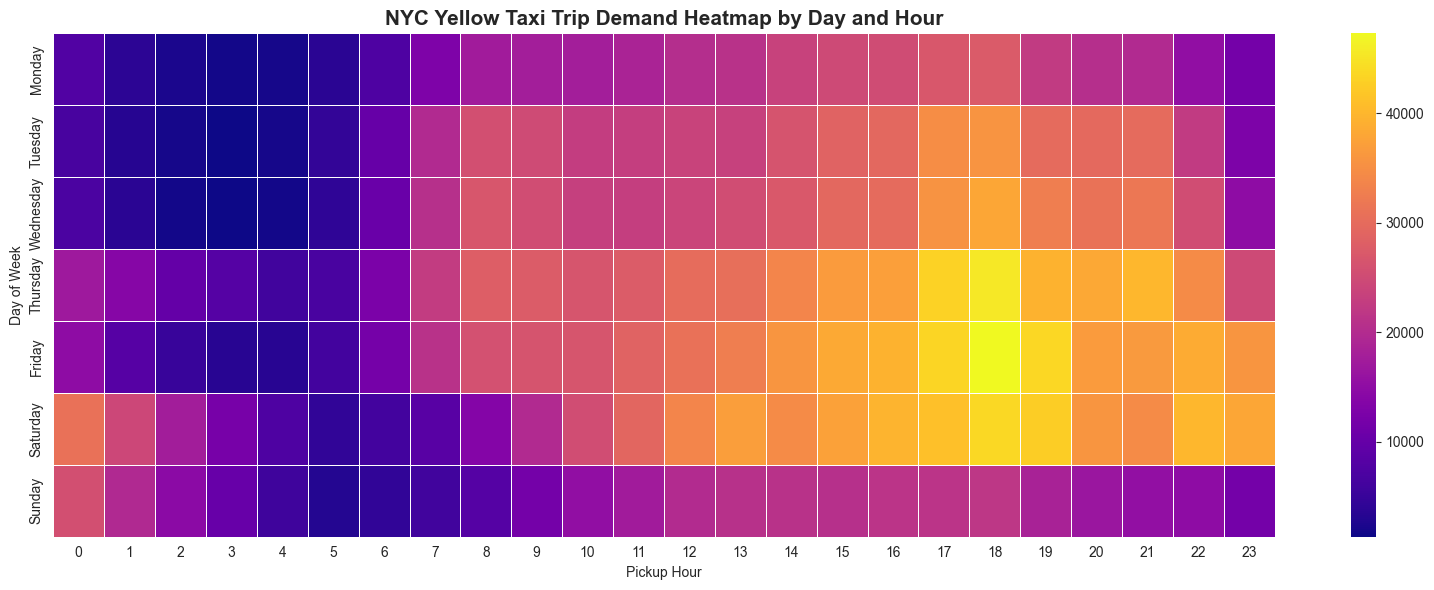

In [21]:
plt.figure(figsize=(16, 6))

sns.heatmap(
    hour_day_pivot,
    cmap="plasma",
    linewidths=0.5,
    linecolor="white"
)

plt.title(
    "NYC Yellow Taxi Trip Demand Heatmap by Day and Hour",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Pickup Hour")
plt.ylabel("Day of Week")

plt.tight_layout()

filepath = os.path.join(
    "img",
    "NYC_Yellow_Taxi_Trip_Demand_Heatmap_by_Day_and_Hour.png"
)

plt.savefig(filepath, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

### Insight: Taxi Demand Heatmap by Day and Hour

The heatmap shows that yellow taxi demand is lowest during the early morning hours, especially between **2 AM and 5 AM**, across almost all days of the week.

Demand starts increasing in the morning around **7 AM to 9 AM**, especially on weekdays, which likely reflects morning commute and daily activity patterns.

The strongest demand appears in the late afternoon and evening, especially around **5 PM to 7 PM**. This pattern is most visible on **Thursday, Friday, and Saturday**, indicating that end-of-week mobility is the busiest period for yellow taxis.

Saturday has consistently high demand from afternoon into evening, suggesting strong weekend activity such as leisure trips, shopping, dining, and nightlife.

Overall, the busiest taxi periods are concentrated during **late afternoon to evening**, while early morning hours have the lowest demand. This confirms that taxi demand is strongly influenced by both time of day and day of week.

### 3.4 Where Do Yellow Taxi Trips Start Most Often?

In [22]:
pickup_borough_trips = (
    df_eda
    .groupby("pickup_borough")
    .size()
    .reset_index(name="trip_count")
    .sort_values("trip_count", ascending=False)
)

pickup_borough_trips

,pickup_borough,trip_count
3,Manhattan,3109339
4,Queens,331711
1,Brooklyn,155238
0,Bronx,36815
6,Unknown,5753
2,EWR,481
5,Staten Island,480


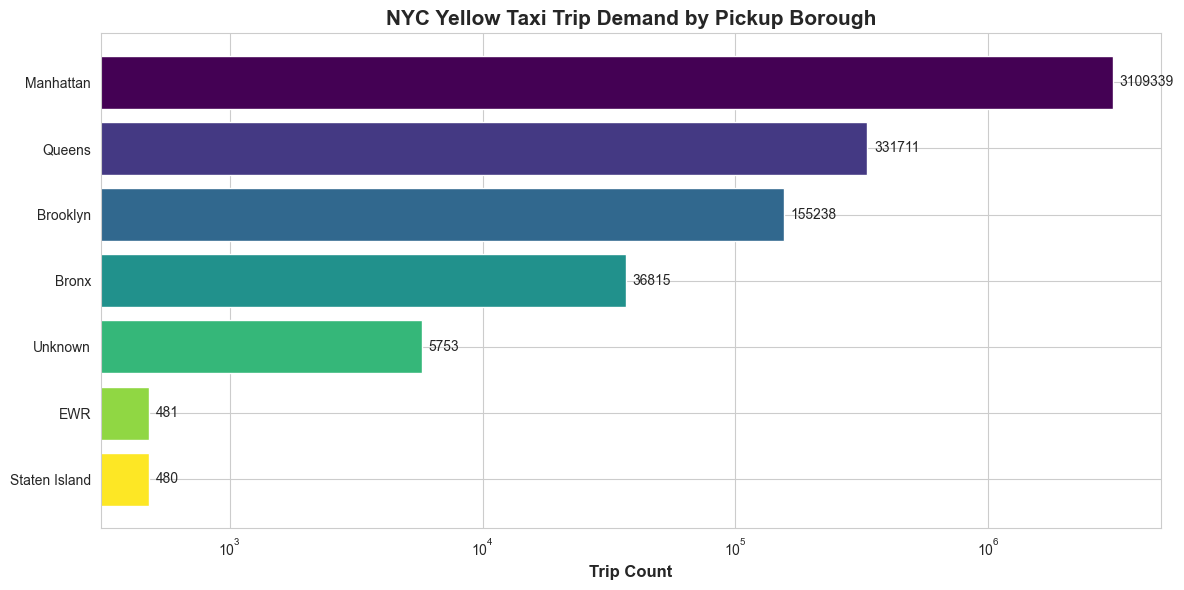

In [23]:
plt.figure(figsize=(12,6))

colors = plt.cm.viridis(np.linspace(0,1, len(pickup_borough_trips)))

barh = plt.barh(
    y=pickup_borough_trips['pickup_borough'],
    width=pickup_borough_trips['trip_count'],
    color=colors
)

plt.title("NYC Yellow Taxi Trip Demand by Pickup Borough",
          fontsize=15,
          fontweight='bold')

plt.xscale('log')
plt.xlabel("Trip Count", fontsize=12, fontweight='bold')
plt.bar_label(barh, fmt="%.0f", padding=5)
plt.gca().invert_yaxis()
plt.tight_layout()

filepath = os.path.join("img",
                        "NYC_Yellow_Taxi_Trip_Demand_by_Pickup_Borough.png")
plt.savefig(filepath, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


### Insight: Trip Demand by Pickup Borough

Pickup demand is highly concentrated in **Manhattan**, with more than **3.1 million trips** starting there. This shows that Manhattan is the dominant origin area for NYC Yellow Taxi trips in this dataset.

Queens and Brooklyn are the next largest pickup boroughs, but their trip volumes are far below Manhattan. Queens has around **331K trips**, while Brooklyn has around **155K trips**, indicating that yellow taxi activity outside Manhattan is much smaller.

The large gap between Manhattan and other boroughs suggests that yellow taxis are still heavily centered around Manhattan’s business districts, tourist areas, hotels, transit hubs, and nightlife zones.

Bronx, Staten Island, EWR, and Unknown pickup locations have much lower trip counts. This may reflect lower yellow taxi availability, different travel behavior, or stronger reliance on other transportation modes in those areas.

Overall, pickup demand is extremely imbalanced across boroughs. Even after using a log scale, Manhattan remains far ahead, confirming that location is a major driver of yellow taxi trip demand.

### 3.5 Where Do Yellow Taxi Trips End Most Often?

In [24]:
dropoff_borough_trips = (
    df_eda.groupby('dropoff_borough')
    .size()
    .reset_index(name='trip_count')
    .sort_values("trip_count", ascending=False)
)
dropoff_borough_trips

,dropoff_borough,trip_count
3,Manhattan,3124239
1,Brooklyn,229242
4,Queens,205697
0,Bronx,52510
6,Unknown,21230
2,EWR,5825
5,Staten Island,1074


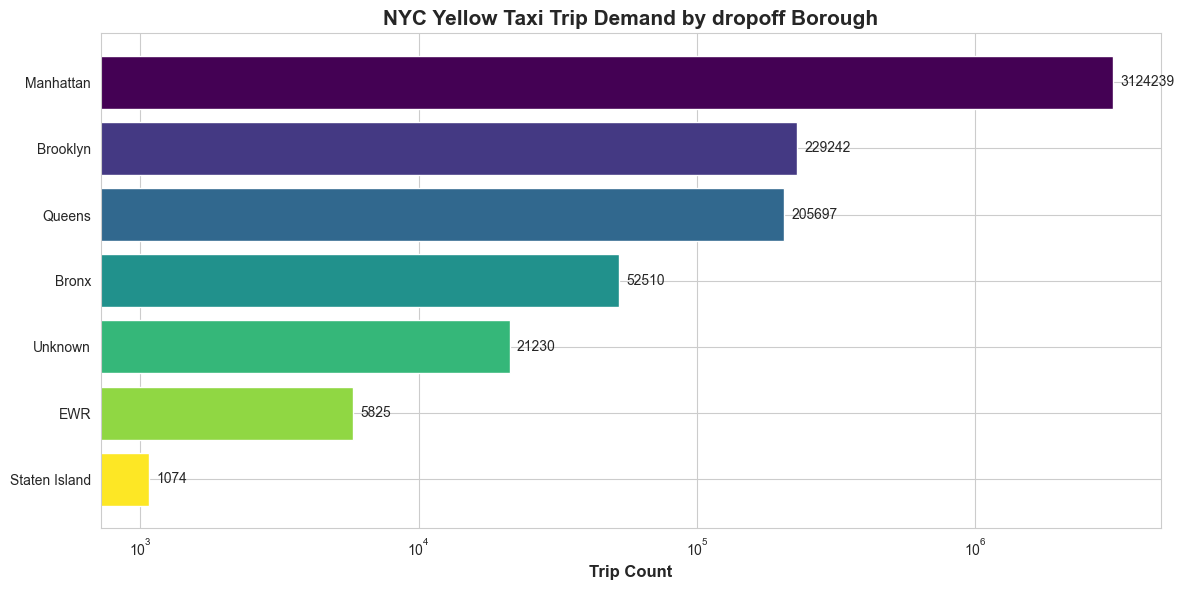

In [25]:
plt.figure(figsize=(12,6))

colors = plt.cm.viridis(np.linspace(0,1, len(dropoff_borough_trips)))

barh = plt.barh(
    y=dropoff_borough_trips['dropoff_borough'],
    width=dropoff_borough_trips['trip_count'],
    color=colors
)

plt.title("NYC Yellow Taxi Trip Demand by dropoff Borough",
          fontsize=15,
          fontweight='bold')

plt.xscale('log')
plt.xlabel("Trip Count", fontsize=12, fontweight='bold')
plt.bar_label(barh, fmt="%.0f", padding=5)
plt.gca().invert_yaxis()
plt.tight_layout()

filepath = os.path.join("img",
                        "NYC_Yellow_Taxi_Trip_Demand_by_dropoff_Borough.png")
plt.savefig(filepath, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


### Insight: Trip Demand by Dropoff Borough

Dropoff demand is also highly concentrated in **Manhattan**, with more than **3.1 million trips** ending there. This shows that Manhattan is not only the main pickup area, but also the dominant destination for yellow taxi trips.

Brooklyn and Queens are the next most common dropoff boroughs, with around **229K** and **206K** trips respectively. Compared to pickup demand, Brooklyn appears slightly stronger as a dropoff destination than Queens.

The Bronx, EWR, Staten Island, and Unknown locations have much lower dropoff volumes. This suggests that yellow taxi trip destinations are still heavily centered around Manhattan and nearby boroughs, while outer areas receive far fewer yellow taxi dropoffs.

The gap between Manhattan and other boroughs remains very large even with a log scale, indicating a strong geographic imbalance in yellow taxi activity.

Overall, the pattern confirms that Manhattan acts as the primary hub for both trip origins and destinations, while Brooklyn and Queens serve as secondary but much smaller demand areas.

### 3.6 Which Borough Routes Are the Most Common?

In [26]:
borough_route_trips = (
    df_eda
    .groupby('borough_route')
    .size()
    .reset_index(name='trip_count')
    .sort_values("trip_count", ascending=False)
)
borough_route_trips.head()

,borough_route,trip_count
20,Manhattan -> Manhattan,2891887
27,Queens -> Manhattan,158109
28,Queens -> Queens,101625
18,Manhattan -> Brooklyn,92372
21,Manhattan -> Queens,82577


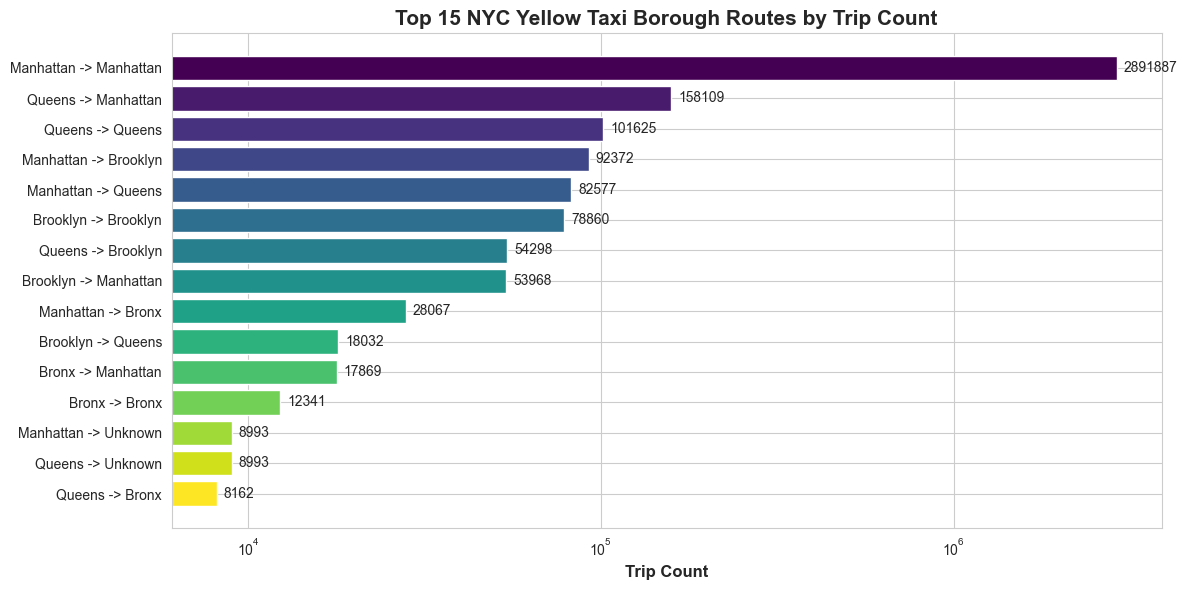

In [27]:
plt.figure(figsize=(12,6))

colors = plt.cm.viridis(np.linspace(0,1, len(borough_route_trips.head(15))))

barh = plt.barh(
    y=borough_route_trips['borough_route'].head(15),
    width=borough_route_trips['trip_count'].head(15),
    color=colors
)

plt.title("Top 15 NYC Yellow Taxi Borough Routes by Trip Count",
          fontsize=15,
          fontweight='bold')

plt.xscale('log')
plt.xlabel("Trip Count", fontsize=12, fontweight='bold')
plt.bar_label(barh, fmt="%.0f", padding=5)
plt.gca().invert_yaxis()
plt.tight_layout()

filepath = os.path.join("img",
                        "Top_15_NYC_Yellow_Taxi_Borough_Routes_by_Trip_Count.png")
plt.savefig(filepath, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


### Insight: Most Common Pickup-to-Dropoff Borough Routes

The most dominant borough route is **Manhattan → Manhattan**, with nearly **2.9 million trips**. This is far higher than any other route, showing that most yellow taxi trips both start and end within Manhattan.

Routes involving Manhattan also dominate the top rankings. Examples include **Queens → Manhattan**, **Manhattan → Brooklyn**, **Manhattan → Queens**, **Brooklyn → Manhattan**, and **Bronx → Manhattan**. This confirms Manhattan’s role as the main hub for yellow taxi activity in NYC.

The second-highest route is **Queens → Manhattan**, which likely reflects airport-related or outer-borough-to-Manhattan travel demand. However, its trip count is still far below Manhattan → Manhattan, showing how concentrated taxi activity is within Manhattan itself.

Same-borough trips such as **Queens → Queens**, **Brooklyn → Brooklyn**, and **Bronx → Bronx** also appear in the top routes, but their volumes are much smaller compared to Manhattan → Manhattan.

Overall, the route pattern shows a highly centralized taxi network, where Manhattan acts as the main origin, destination, and internal travel zone for yellow taxi trips.

### 3.7 How Does Average Fare Vary by Pickup Borough?

In [28]:
pickup_borough_fare = (
    df_eda[df_eda["trip_distance"] >= 0.5]
    .groupby("pickup_borough")
    .agg(
        trip_count=("pickup_borough", "size"),
        mean_fare_per_mile=("fare_per_mile", "mean"),
        median_fare_per_mile=("fare_per_mile", "median")
    )
    .reset_index()
    .sort_values("median_fare_per_mile", ascending=False)
)

pickup_borough_fare

,pickup_borough,trip_count,mean_fare_per_mile,median_fare_per_mile
2,EWR,23,57.221250,11.076923
3,Manhattan,2861584,8.613381,7.753623
6,Unknown,4328,8.510054,7.166667
1,Brooklyn,142818,6.975020,5.957392
5,Staten Island,439,5.509688,4.733121
0,Bronx,34609,5.721226,4.453125
4,Queens,314217,5.046630,4.179431


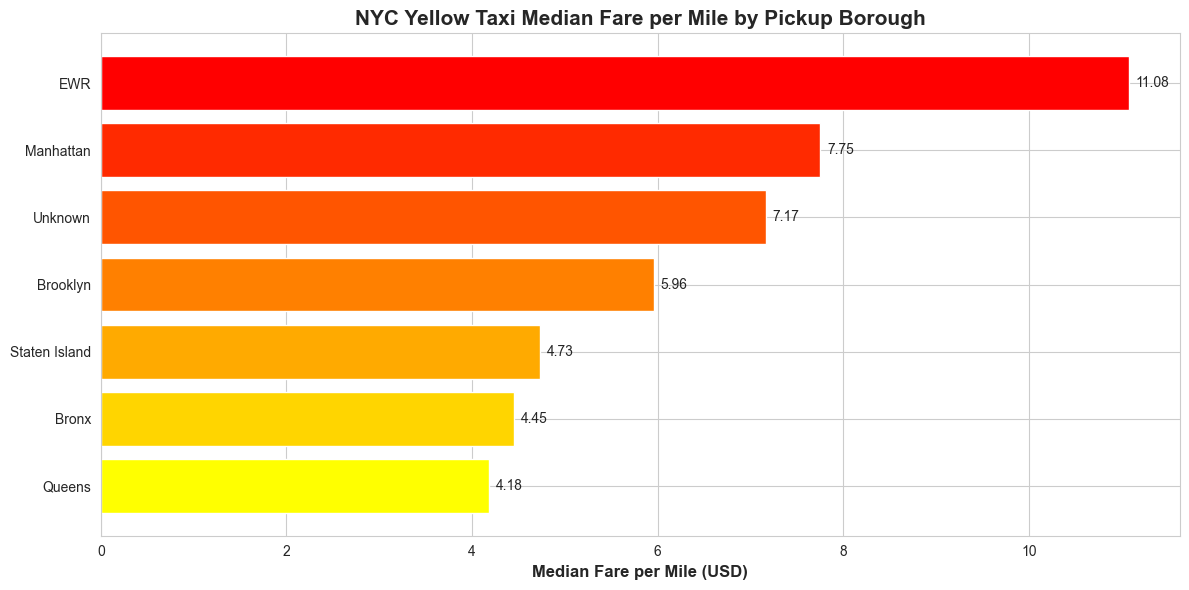

In [29]:
plt.figure(figsize=(12,6))

colors = plt.cm.autumn(np.linspace(0, 1, len(pickup_borough_fare)))

barh = plt.barh(
    y=pickup_borough_fare["pickup_borough"],
    width=pickup_borough_fare["median_fare_per_mile"],
    color=colors
)

plt.title(
    "NYC Yellow Taxi Median Fare per Mile by Pickup Borough",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Median Fare per Mile (USD)", fontsize=12, fontweight="bold")
plt.bar_label(barh, fmt="%.2f", padding=5)
plt.gca().invert_yaxis()
plt.tight_layout()

filepath = os.path.join(
    "img",
    "NYC_Yellow_Taxi_Median_Fare_per_Mile_by_Pickup_Borough.png"
)

plt.savefig(filepath, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

### Insight: Median Fare per Mile by Pickup Borough

The highest median fare per mile comes from **EWR**, at around **$11.08 per mile**. This is likely influenced by airport-related trips, fixed fees, airport surcharges, tolls, and the fact that airport pickups often have different pricing patterns compared to regular city trips.

**Manhattan** has the second-highest median fare per mile at around **$7.75**, which may reflect dense urban traffic, shorter trip distances, congestion-related charges, and higher taxi demand in central business and tourist areas.

**Queens** has the lowest median fare per mile among the listed boroughs, at around **$4.18**. This may indicate longer average trip distances or less fee-heavy trip patterns compared to EWR and Manhattan.

The high value for **Unknown** should be interpreted carefully because these records do not have a clearly identified borough. They may include special zones, incomplete location labels, or unusual trip records.

Overall, fare per mile varies meaningfully by pickup borough. Airport-related pickups and dense central areas tend to have higher median fare per mile, while outer borough pickups generally show lower fare per mile.

### 3.8 How Did Cumulative Fare Amount Grow During January 2026?

In [30]:
df_eda["pickup_date"] = pd.to_datetime(df_eda["pickup_date"])

daily_fare = (
    df_eda[df_eda['pickup_date'] > '2025-12-31']
    .groupby('pickup_date')
    .agg(
        daily_trip_count=("pickup_date", "size"),
        daily_fare_amount=("fare_amount", "sum"),
        daily_total_amount=("total_amount", "sum")
    )
    .reset_index()
    .sort_values("pickup_date")
)

daily_fare['cumulative_trip_count'] = daily_fare['daily_trip_count'].cumsum()
daily_fare['cumulative_fare_amount'] = daily_fare['daily_fare_amount'].cumsum()
daily_fare['cumulative_total_amount'] = daily_fare['daily_total_amount'].cumsum()

daily_fare.head()

,pickup_date,daily_trip_count,daily_fare_amount,daily_total_amount,cumulative_trip_count,cumulative_fare_amount,cumulative_total_amount
0,2026-01-01,111814,2701550.33,3620986.40,111814,2701550.33,3620986.40
1,2026-01-02,97549,2104724.65,2969006.35,209363,4806274.98,6589992.75
2,2026-01-03,105737,2238087.32,3114800.24,315100,7044362.30,9704792.99
3,2026-01-04,91131,2038808.64,2817948.52,406231,9083170.94,12522741.51
4,2026-01-05,94806,2076388.44,2924638.41,501037,11159559.38,15447379.92


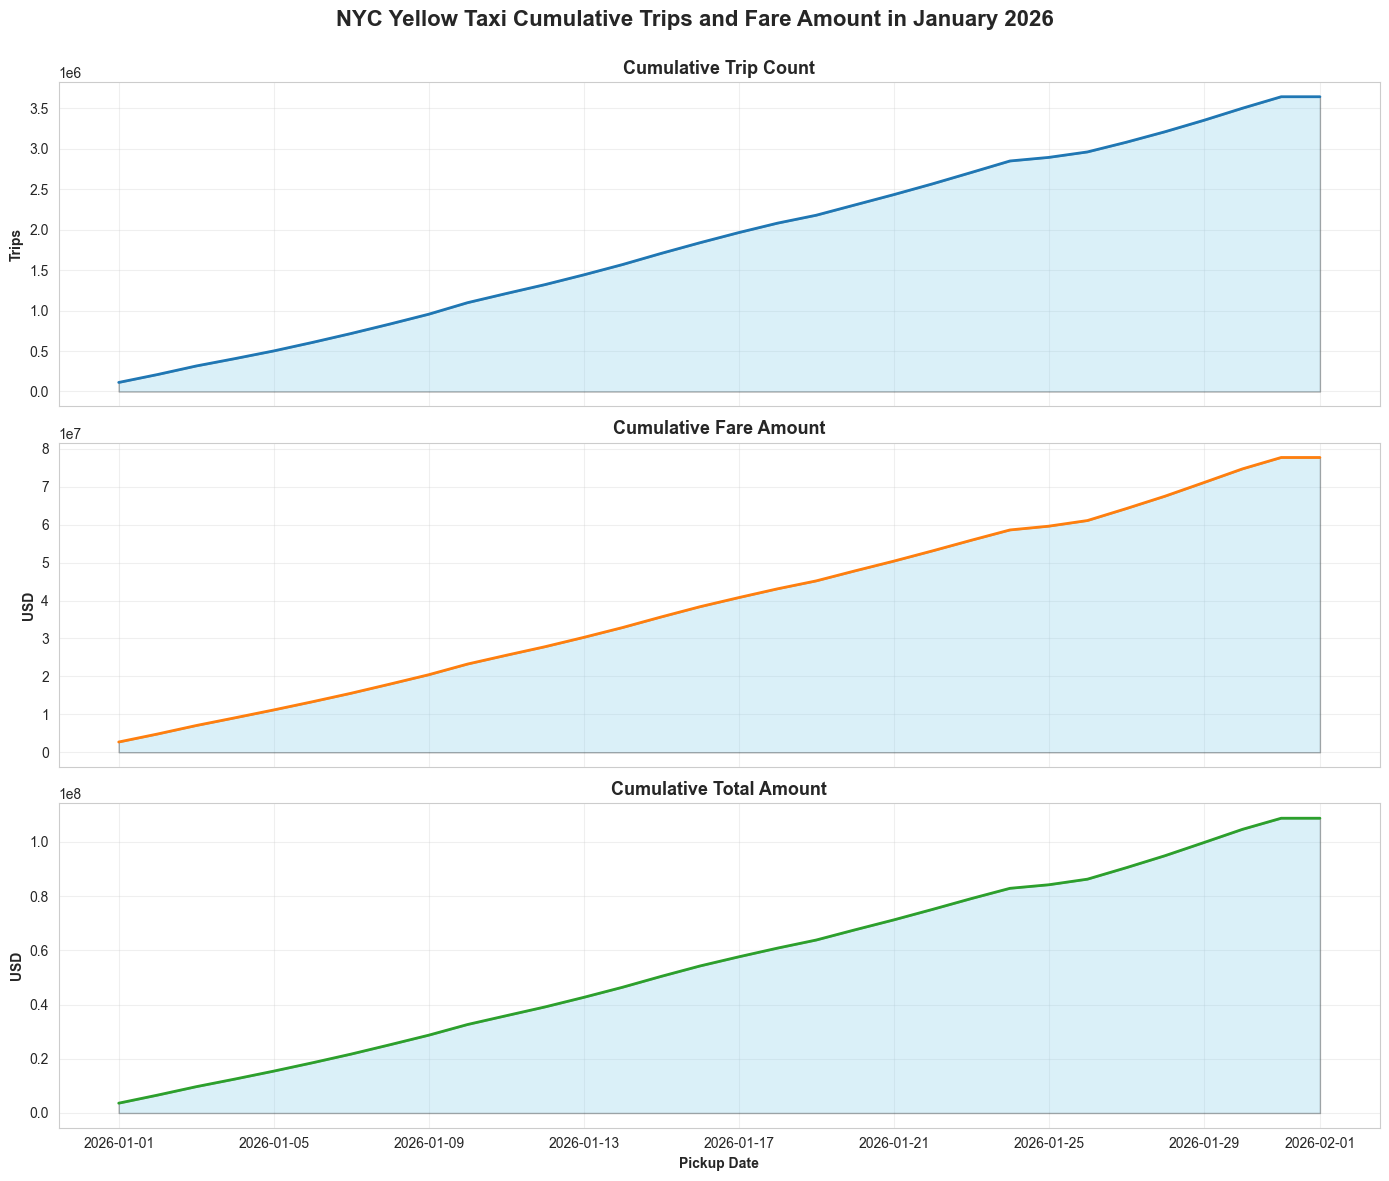

In [31]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

plots = [
    ("cumulative_trip_count", "Cumulative Trip Count", "Trips", "#1f77b4"),
    ("cumulative_fare_amount", "Cumulative Fare Amount", "USD", "#ff7f0e"),
    ("cumulative_total_amount", "Cumulative Total Amount", "USD", "#2ca02c")
]

for ax, (col, title, ylabel, color) in zip(axes, plots):
    ax.plot(
        daily_fare["pickup_date"],
        daily_fare[col],
        linewidth=2,
        color=color
    )

    ax.fill_between(daily_fare['pickup_date'],
                    daily_fare[col].values,
                    alpha=0.3, color='skyblue', edgecolor='black')

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel(ylabel, fontweight="bold")
    ax.grid(True, alpha=0.3)

fig.suptitle(
    "NYC Yellow Taxi Cumulative Trips and Fare Amount in January 2026",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Pickup Date", fontweight="bold")
plt.tight_layout()
fig.subplots_adjust(top=0.92)

filepath = os.path.join(
    "img",
    "NYC_Yellow_Taxi_Cumulative_Trips_and_Fare_Amount_in_January_2026.png"
)

plt.savefig(filepath, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

### Insight: Cumulative Trips and Fare Amount in January 2026

The cumulative trip count, cumulative fare amount, and cumulative total amount all show a steady upward trend throughout January 2026. This indicates that taxi activity and revenue accumulated consistently across the month.

The shape of the three curves is very similar, suggesting a strong relationship between trip volume and revenue. As the number of trips increases, both fare amount and total amount also increase in a similar pattern.

Cumulative total amount is consistently higher than cumulative fare amount because it includes additional components such as tips, tolls, surcharges, taxes, and other fees beyond the base fare.

There are small changes in slope across the month, which may reflect daily demand differences such as weekdays, weekends, or peak travel periods. However, the overall trend remains stable without any major drops or irregular breaks.

Overall, the chart shows that January 2026 yellow taxi revenue growth is mainly driven by consistent trip accumulation, with total revenue growing alongside trip count and base fare revenue.

### 3.9 How Does Trip Duration Change Across Distance Categories?

In [32]:
distance_order = ["Very Short", "Short", "Medium", "Long", "Very Long"]

duration_by_distance = df_eda[
    (df_eda["trip_duration_min"] > 0) &
    (df_eda["trip_duration_min"] <= df_eda["trip_duration_min"].quantile(0.99))
].copy()

duration_by_distance["distance_category"] = pd.Categorical(
    duration_by_distance["distance_category"],
    categories=distance_order,
    ordered=True
)

duration_by_distance

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,trip_duration_min,pickup_date,pickup_hour,pickup_dayofweek,pickup_day_name,is_weekend,pickup_period,is_rush_hour,is_night,speed_mph,tip_percentage,fare_per_mile,distance_category,route_id,pickup_borough,pickup_zone,pickup_service_zone,dropoff_borough,dropoff_zone,dropoff_service_zone,borough_route,zone_route,is_interborough_trip
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.20,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00,5.550000,2026-01-01,0,3,Thursday,0,Late Night,0,1,10.486486,50.833333,7.422680,Very Short,239 -> 238,Manhattan,Upper West Side South,Yellow Zone,Manhattan,Upper West Side North,Yellow Zone,Manhattan -> Manhattan,Upper West Side South -> Upper West Side North,0
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.90,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75,5.716667,2026-01-01,0,3,Thursday,0,Late Night,0,1,9.446064,0.000000,8.777778,Very Short,163 -> 162,Manhattan,Midtown North,Yellow Zone,Manhattan,Midtown East,Yellow Zone,Manhattan -> Manhattan,Midtown North -> Midtown East,0
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.70,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75,8.883333,2026-01-01,0,3,Thursday,0,Late Night,0,1,9.455910,23.364486,7.642857,Short,43 -> 237,Manhattan,Central Park,Yellow Zone,Manhattan,Upper East Side South,Yellow Zone,Manhattan -> Manhattan,Central Park -> Upper East Side South,0
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.70,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75,42.800000,2026-01-01,0,3,Thursday,0,Late Night,0,1,7.822430,28.708010,6.935484,Medium,142 -> 209,Manhattan,Lincoln Square East,Yellow Zone,Manhattan,Seaport,Yellow Zone,Manhattan -> Manhattan,Lincoln Square East -> Seaport,0
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.50,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75,13.500000,2026-01-01,0,3,Thursday,0,Late Night,0,1,9.600000,28.518519,6.250000,Short,88 -> 144,Manhattan,Financial District South,Yellow Zone,Manhattan,Little Italy/NoLiTa,Yellow Zone,Manhattan -> Manhattan,Financial District South -> Little Italy/NoLiTa,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3639812,2,2026-01-31 23:26:00,2026-01-31 23:39:16,NaN,1.62,NaN,None,237,161,0,17.09,0.00,0.5,0.00,0.0,1.0,21.84,NaN,NaN,0.75,13.266667,2026-01-31,23,5,Saturday,1,Night,0,0,7.326633,0.000000,10.549383,Short,237 -> 161,Manhattan,Upper East Side South,Yellow Zone,Manhattan,Midtown Center,Yellow Zone,Manhattan -> Manhattan,Upper East Side South -> Midtown Center,0
3639813,2,2026-01-31 23:33:53,2026-01-31 23:34:07,NaN,0.00,NaN,None,42,42,0,23.19,0.00,0.5,0.00,0.0,1.0,24.69,NaN,NaN,0.00,0.233333,2026-01-31,23,5,Saturday,1,Night,0,0,0.000000,0.000000,NaN,Very Short,42 -> 42,Manhattan,Central Harlem North,Boro Zone,Manhattan,Central Harlem North,Boro Zone,Manhattan -> Manhattan,Central Harlem North -> Central Harlem North,0
3639814,2,2026-01-31 23:40:23,2026-01-31 23:56:10,NaN,6.84,NaN,None,137,69,0,29.21,0.00,0.5,0.00,0.0,1.0,33.96,NaN,NaN,0.75,15.783333,2026-01-31,23,5,Saturday,1,Night,0,0,26.002112,0.000000,4.270468,Medium,137 -> 69,Manhattan,Kips Bay,Yellow Zone,Bronx,East Concourse/Concourse Village,Boro Zone,Manhattan -> Bronx,Kips Bay -> East Concourse/Concourse Village,1
3639815,2,2026-01-31 23:10:21,2026-01-31 23:20:00,NaN,1.53,NaN,None,137,162,0,19.19,0.00,0.5,0.00,0.0,1.0,23.94,NaN,NaN,0.75,9.650000,2026-01-31,23,5,Saturday,1,Night,0,0,9.512953,0.000000,12.542484,Short,137 -> 162,Manhattan,Kips Bay,Yellow Zone,Manhattan,Midtown East,Yellow Zone,Manhattan -> Manhattan,Kips Bay -> Midtown East,0


C:\Users\FATHIR\AppData\Local\Temp\ipykernel_3708\633873360.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


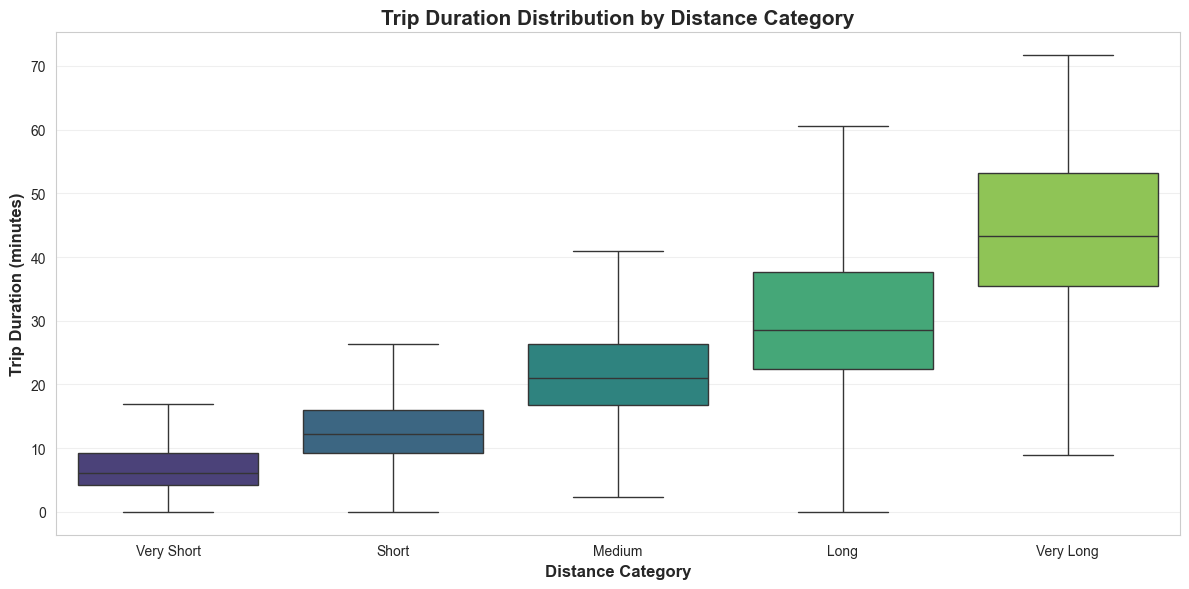

In [33]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=duration_by_distance,
    x="distance_category",
    y="trip_duration_min",
    order=distance_order,
    showfliers=False,
    palette="viridis"
)

plt.title(
    "Trip Duration Distribution by Distance Category",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Distance Category", fontsize=12, fontweight="bold")
plt.ylabel("Trip Duration (minutes)", fontsize=12, fontweight="bold")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

filepath = os.path.join(
    "img",
    "Trip_Duration_Distribution_by_Distance_Category.png"
)

plt.savefig(filepath, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

### Insight: Trip Duration by Distance Category

Trip duration increases consistently as distance category becomes longer. Very short trips have the lowest median duration, while very long trips have the highest median duration.

The boxplot shows that distance is strongly related to trip duration, but the relationship is not perfectly fixed. Each distance category still has a fairly wide duration range, meaning trips with similar distances can take different amounts of time.

This variation is likely influenced by traffic congestion, pickup/dropoff location, road type, waiting time, and whether the trip happens in dense areas such as Manhattan or on faster routes such as highways.

The spread becomes wider for longer distance categories, especially for `Long` and `Very Long` trips. This suggests that longer trips are more variable and less predictable in terms of duration.

Overall, trip distance is an important driver of trip duration, but it is not the only factor. This supports the idea that additional features such as pickup hour, borough route, and traffic-related patterns may be useful for later machine learning.

### 3.10 How Does Average Speed Vary by Pickup Hour?

In [34]:
hourly_speed = (
    df_eda[
        (df_eda["speed_mph"] > 0) &
        (df_eda["speed_mph"] <= df_eda["speed_mph"].quantile(0.99))
    ]
    .groupby("pickup_hour")
    .agg(
        trip_count=("pickup_hour", "size"),
        median_speed_mph=("speed_mph", "median"),
        avg_speed_mph=("speed_mph", "mean")
    )
    .reset_index()
    .sort_values("pickup_hour")
)

hourly_speed

,pickup_hour,trip_count,median_speed_mph,avg_speed_mph
0,0,105157,12.039152,13.652435
1,1,73451,12.326400,13.598399
2,2,51176,12.883276,14.017717
3,3,36232,13.655172,14.825859
4,4,26415,14.803738,16.195060
5,5,30187,15.277652,16.874430
6,6,60453,13.381924,14.847741
7,7,108723,10.909091,12.183966
8,8,142396,9.285108,10.586423
9,9,150398,9.053254,10.386907


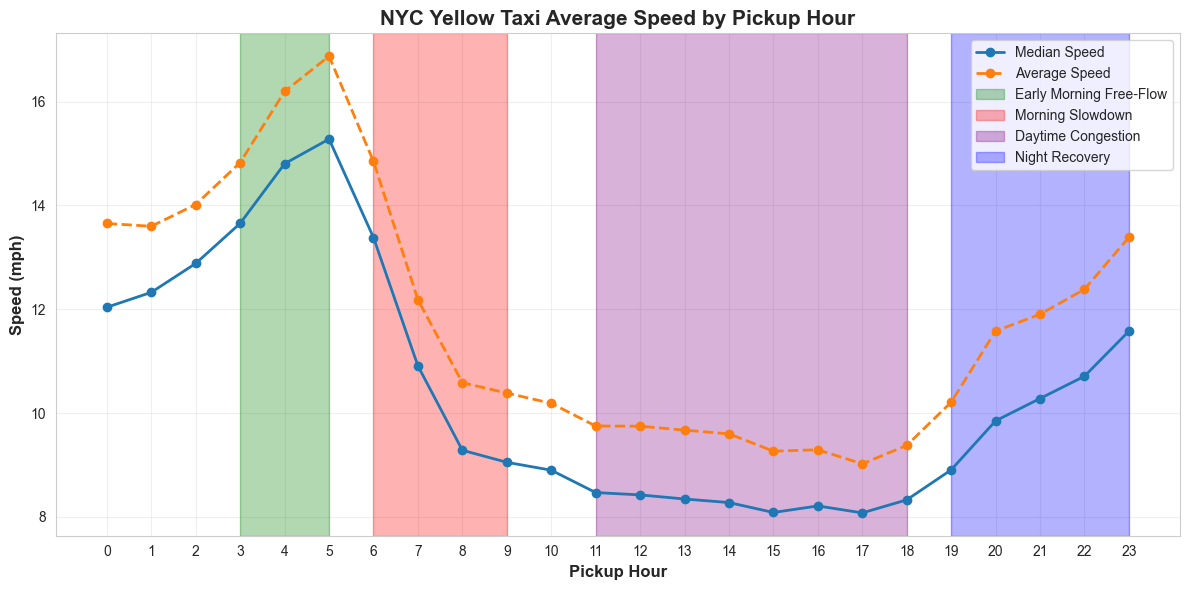

In [35]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    hourly_speed["pickup_hour"],
    hourly_speed["median_speed_mph"],
    marker="o",
    linewidth=2,
    label="Median Speed",
    color="#1f77b4"
)

ax.plot(
    hourly_speed["pickup_hour"],
    hourly_speed["avg_speed_mph"],
    marker="o",
    linewidth=2,
    linestyle="--",
    label="Average Speed",
    color="#ff7f0e"
)

ax.axvspan(3, 5, color="green", alpha=0.3, label="Early Morning Free-Flow")
ax.axvspan(6, 9, color="red", alpha=0.3, label="Morning Slowdown")
ax.axvspan(11, 18, color="purple", alpha=0.30, label="Daytime Congestion")
ax.axvspan(19, 23, color="blue", alpha=0.3, label="Night Recovery")

ax.set_title(
    "NYC Yellow Taxi Average Speed by Pickup Hour",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Pickup Hour", fontsize=12, fontweight="bold")
ax.set_ylabel("Speed (mph)", fontsize=12, fontweight="bold")
ax.set_xticks(range(0, 24))
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()

filepath = os.path.join(
    "img",
    "NYC_Yellow_Taxi_Average_Speed_by_Pickup_Hour.png"
)

plt.savefig(filepath, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

### Insight: Average Speed by Pickup Hour

Taxi speed shows a clear daily traffic pattern. The highest speed occurs during the early morning free-flow period, especially around 3 AM to 5 AM, when road activity is still relatively low and taxis can move faster.

After 6 AM, speed drops sharply during the morning slowdown period. This suggests that congestion starts early in NYC as commuting, school trips, deliveries, and general city activity begin to increase.

The slowest period appears during the daytime congestion window, especially from late morning to late afternoon. Median speed stays around 8–9 mph, showing that NYC taxi movement remains slow throughout business hours, not only during classic rush hour.

Speed starts recovering after 7 PM and continues improving into late night. This indicates that traffic pressure gradually decreases after the main daytime activity ends.

Overall, pickup hour has a strong relationship with trip efficiency. This makes `pickup_hour` an important feature for further analysis and potential machine learning models related to trip duration or taxi speed.

### 3.11 How Do Trip Characteristics Differ by Passenger Count?

In [36]:
passenger_summary = (
    df_eda
    .dropna(subset=["passenger_count"])
    .query("passenger_count.between(1, 6)")
    .groupby("passenger_count")
    .agg(
        trip_count=("passenger_count", "size"),
        median_trip_distance=("trip_distance", "median"),
        median_trip_duration=("trip_duration_min", "median"),
        median_total_amount=("total_amount", "median"),
        median_fare_per_mile=("fare_per_mile", "median")
    )
    .reset_index()
    .sort_values("passenger_count")
)

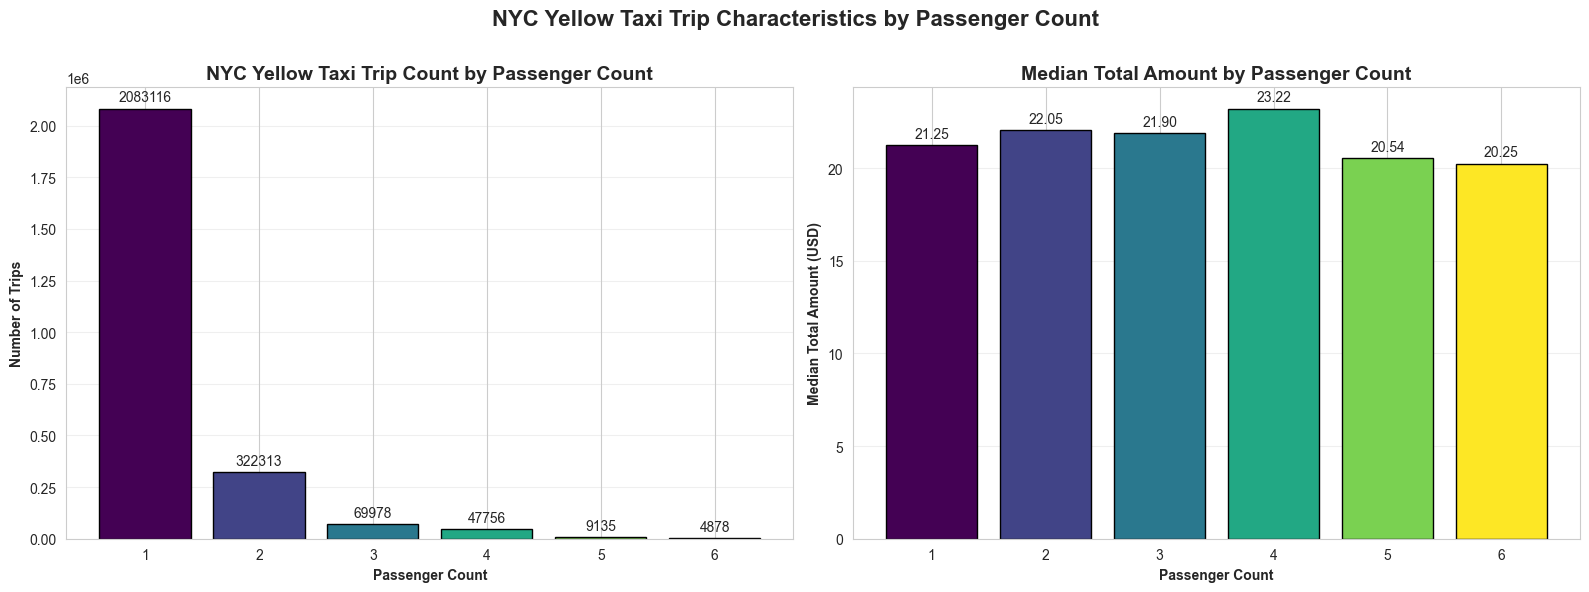

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = plt.cm.viridis(np.linspace(0, 1, len(passenger_summary)))

bars1 = axes[0].bar(
    passenger_summary["passenger_count"].astype(str),
    passenger_summary["trip_count"],
    color=colors,
    edgecolor="black"
)

axes[0].set_title(
    "NYC Yellow Taxi Trip Count by Passenger Count",
    fontsize=14,
    fontweight="bold"
)
axes[0].set_xlabel("Passenger Count", fontweight="bold")
axes[0].set_ylabel("Number of Trips", fontweight="bold")
axes[0].bar_label(bars1, fmt="%.0f", padding=3)
axes[0].grid(axis="y", alpha=0.3)
axes[0].set_xticks(range(len(passenger_summary)))
axes[0].set_xticklabels(
    passenger_summary["passenger_count"].astype(int)
)

bars2 = axes[1].bar(
    passenger_summary["passenger_count"].astype(str),
    passenger_summary["median_total_amount"],
    color=colors,
    edgecolor="black"
)

axes[1].set_title(
    "Median Total Amount by Passenger Count",
    fontsize=14,
    fontweight="bold"
)
axes[1].set_xlabel("Passenger Count", fontweight="bold")
axes[1].set_ylabel("Median Total Amount (USD)", fontweight="bold")
axes[1].bar_label(bars2, fmt="%.2f", padding=3)
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_xticks(range(len(passenger_summary)))
axes[1].set_xticklabels(
    passenger_summary["passenger_count"].astype(int)
)


fig.suptitle(
    "NYC Yellow Taxi Trip Characteristics by Passenger Count",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
fig.subplots_adjust(top=0.85)

filepath = os.path.join(
    "img",
    "NYC_Yellow_Taxi_Trip_Characteristics_by_Passenger_Count.png"
)

plt.savefig(filepath, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

### Insight: Trip Characteristics by Passenger Count

- NYC Yellow Taxi trips are strongly dominated by solo passengers, with over **2.08 million trips**. Two-passenger trips are a distant second at around **322 thousand trips**, while trips with five or six passengers are relatively rare.

- Despite the large difference in trip volume, the median total amount is remarkably consistent across passenger groups, ranging from roughly **$20 to $23**.

- Trips with four passengers have the highest median total amount at **$23.22**, but this difference is still modest compared with the other groups.

- This suggests that passenger count has limited influence on trip cost. Fare is likely driven more by trip distance, duration, traffic conditions, route, and applicable surcharges than by the number of passengers.

- For modelling, `passenger_count` can remain as an additional feature, but it is unlikely to be one of the strongest predictors of total trip cost or duration.

3.12 How Do Payment Methods Differ Across NYC Yellow Taxi Trips?

In [38]:
payment_type_map = {
    0: "Flex Fare Trip",
    1: "Credit Card",
    2: "Cash",
    3: "No Charge",
    4: "Dispute",
    5: "Unknown",
    6: "Voided Trip"
}

payment_summary = (
    df_eda
    .assign(
        payment_method=lambda data: (
            data["payment_type"].map(payment_type_map)
        )
    )
    .groupby("payment_method", dropna=False)
    .agg(
        trip_count=("payment_type", "size"),
        median_total_amount=("total_amount", "median")
    )
    .reset_index()
)

payment_summary["trip_share_pct"] = (
    payment_summary["trip_count"] / payment_summary["trip_count"].sum() * 100
)

payment_summary = payment_summary.sort_values(
    "trip_count",
    ascending=False
)

payment_summary

,payment_method,trip_count,median_total_amount,trip_share_pct
1,Credit Card,2210284,21.90,60.725141
3,Flex Fare Trip,1087978,28.08,29.891008
0,Cash,299701,17.80,8.233958
2,Dispute,30157,18.25,0.828531
4,No Charge,11697,14.45,0.321362


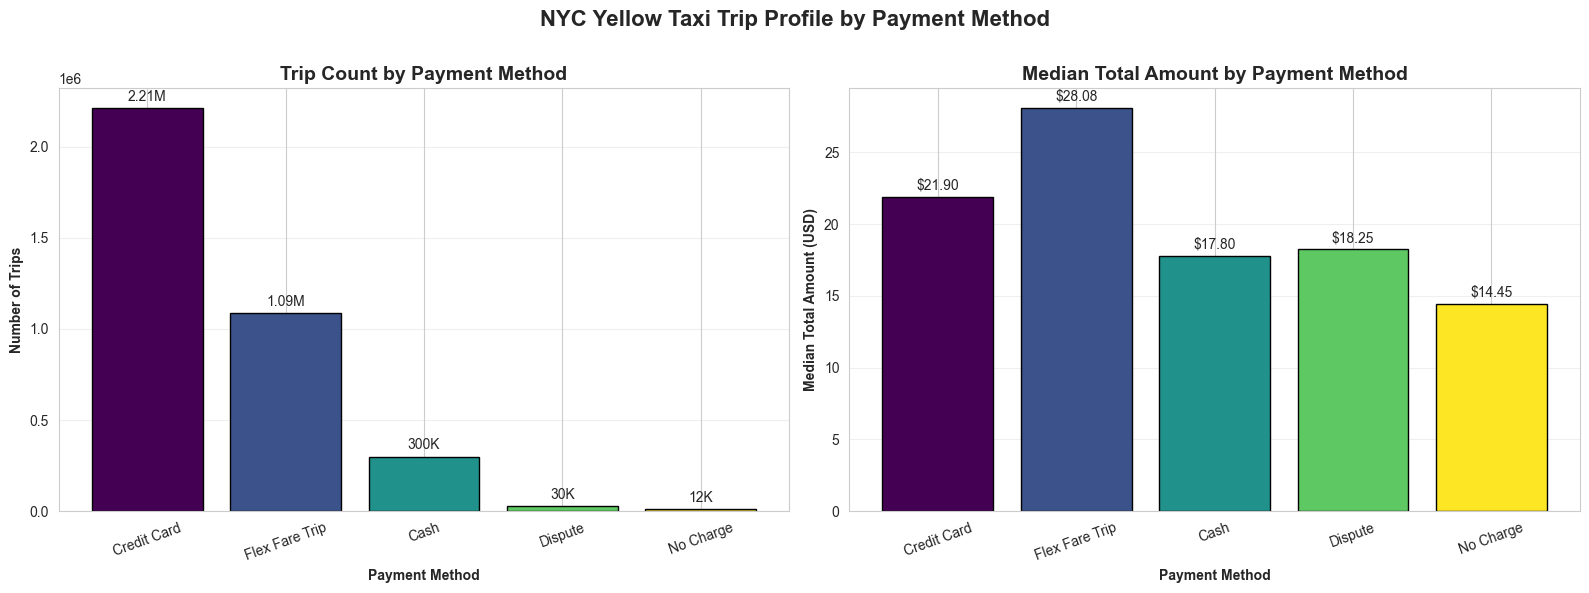

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = plt.cm.viridis(
    np.linspace(0, 1, len(payment_summary))
)

trip_labels = [
    f"{value / 1_000_000:.2f}M"
    if value >= 1_000_000
    else f"{value / 1_000:.0f}K"
    for value in payment_summary["trip_count"]
]

bars1 = axes[0].bar(
    payment_summary["payment_method"],
    payment_summary["trip_count"],
    color=colors,
    edgecolor="black"
)

axes[0].bar_label(
    bars1,
    labels=trip_labels,
    padding=3,
    fontsize=10
)

axes[0].set_title(
    "Trip Count by Payment Method",
    fontsize=14,
    fontweight="bold"
)
axes[0].set_xlabel("Payment Method", fontweight="bold")
axes[0].set_ylabel("Number of Trips", fontweight="bold")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", alpha=0.3)


bars2 = axes[1].bar(
    payment_summary["payment_method"],
    payment_summary["median_total_amount"],
    color=colors,
    edgecolor="black"
)

axes[1].bar_label(
    bars2,
    fmt="$%.2f",
    padding=3,
    fontsize=10
)

axes[1].set_title(
    "Median Total Amount by Payment Method",
    fontsize=14,
    fontweight="bold"
)
axes[1].set_xlabel("Payment Method", fontweight="bold")
axes[1].set_ylabel("Median Total Amount (USD)", fontweight="bold")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y", alpha=0.3)


fig.suptitle(
    "NYC Yellow Taxi Trip Profile by Payment Method",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
fig.subplots_adjust(top=0.85)

filepath = os.path.join(
    "img",
    "NYC_Yellow_Taxi_Trip_Profile_by_Payment_Method.png"
)

plt.savefig(
    filepath,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

### Insight: Trip Profile by Payment Method

- **Credit Card** is the dominant payment method, accounting for approximately **2.21 million trips**. This represents the majority of NYC Yellow Taxi transactions during January 2026.

- **Flex Fare Trip** is the second-largest category with around **1.09 million trips**, making it a substantial part of the dataset rather than a minor exception.

- Flex Fare trips have the highest median total amount at **$28.08**, compared with **$21.90** for credit-card trips and **$17.80** for cash trips. This suggests that Flex Fare trips may be associated with higher-value journeys, different pricing rules, or additional charges.

- Cash trips are much less common than credit-card trips and have a lower median total amount. However, this chart should not be used to compare tipping behavior because cash tips may not be fully recorded in the dataset.

- **Dispute** and **No Charge** transactions are rare, so their median amounts should be interpreted cautiously due to their much smaller number of trips.

### 3.13 How Do Interborough Trips Differ from Within-Borough Trips?

In [40]:
trip_scope_summary = (
    df_eda[
        (df_eda["pickup_borough"] != "Unknown") &
        (df_eda["dropoff_borough"] != "Unknown")
    ]
    .assign(
        trip_scope=lambda data: np.where(
            data["is_interborough_trip"] == 1,
            "Interborough",
            "Within Borough"
        )
    )
    .groupby("trip_scope")
    .agg(
        trip_count=("trip_scope", "size"),
        median_trip_distance=("trip_distance", "median"),
        median_total_amount=("total_amount", "median")
    )
    .reindex(["Within Borough", "Interborough"])
    .reset_index()
)

trip_scope_summary["trip_share_pct"] = (
    trip_scope_summary["trip_count"] /
    trip_scope_summary["trip_count"].sum() * 100
)

trip_scope_summary

,trip_scope,trip_count,median_trip_distance,median_total_amount,trip_share_pct
0,Within Borough,3085331,1.56,21.4,85.331593
1,Interborough,530365,9.33,55.0,14.668407


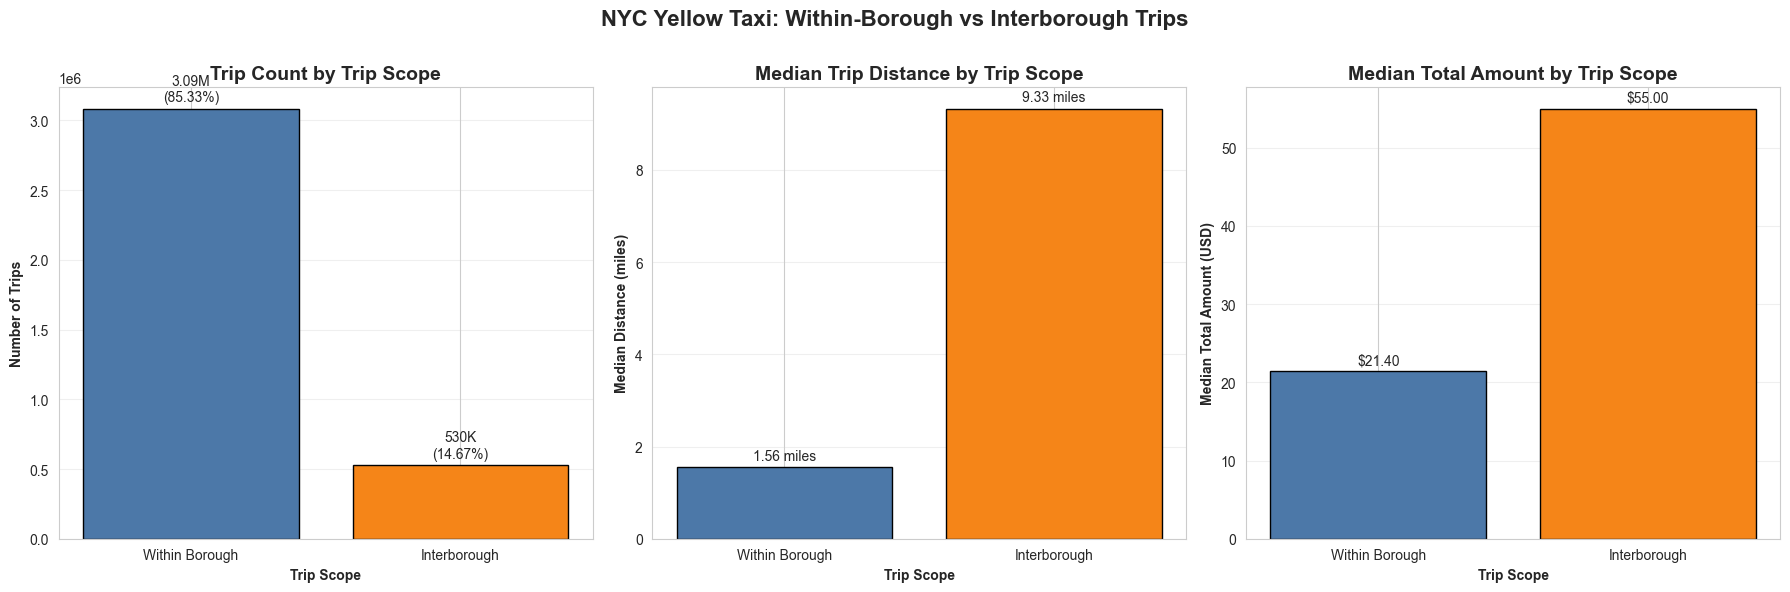

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ["#4C78A8", "#F58518"]

trip_labels = [
    f"{trip_count / 1_000_000:.2f}M\n({share:.2f}%)"
    if trip_count >= 1_000_000
    else f"{trip_count / 1_000:.0f}K\n({share:.2f}%)"
    for trip_count, share in zip(
        trip_scope_summary["trip_count"],
        trip_scope_summary["trip_share_pct"]
    )
]

# Trip count
bars1 = axes[0].bar(
    trip_scope_summary["trip_scope"],
    trip_scope_summary["trip_count"],
    color=colors,
    edgecolor="black"
)

axes[0].bar_label(
    bars1,
    labels=trip_labels,
    padding=3,
    fontsize=10
)

axes[0].set_title(
    "Trip Count by Trip Scope",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("Trip Scope", fontweight="bold")
axes[0].set_ylabel("Number of Trips", fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)


# Median distance
bars2 = axes[1].bar(
    trip_scope_summary["trip_scope"],
    trip_scope_summary["median_trip_distance"],
    color=colors,
    edgecolor="black"
)

axes[1].bar_label(
    bars2,
    fmt="%.2f miles",
    padding=3,
    fontsize=10
)

axes[1].set_title(
    "Median Trip Distance by Trip Scope",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("Trip Scope", fontweight="bold")
axes[1].set_ylabel("Median Distance (miles)", fontweight="bold")
axes[1].grid(axis="y", alpha=0.3)


# Median total amount
bars3 = axes[2].bar(
    trip_scope_summary["trip_scope"],
    trip_scope_summary["median_total_amount"],
    color=colors,
    edgecolor="black"
)

axes[2].bar_label(
    bars3,
    fmt="$%.2f",
    padding=3,
    fontsize=10
)

axes[2].set_title(
    "Median Total Amount by Trip Scope",
    fontsize=14,
    fontweight="bold"
)

axes[2].set_xlabel("Trip Scope", fontweight="bold")
axes[2].set_ylabel("Median Total Amount (USD)", fontweight="bold")
axes[2].grid(axis="y", alpha=0.3)


fig.suptitle(
    "NYC Yellow Taxi: Within-Borough vs Interborough Trips",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
fig.subplots_adjust(top=0.85)

filepath = os.path.join(
    "img",
    "NYC_Yellow_Taxi_Within_Borough_vs_Interborough_Trips.png"
)

plt.savefig(
    filepath,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

### Insight: Within-Borough vs Interborough Trips

- Most NYC Yellow Taxi trips remain within the same borough, accounting for approximately **3.09 million trips (85.33%)**. This aligns with the earlier finding that Manhattan-to-Manhattan is the dominant borough route.

- Interborough trips represent only **14.67%** of total trips, but they are substantially longer. Their median distance is **9.33 miles**, almost six times the **1.56 miles** recorded for within-borough trips.

- The longer distance of interborough trips is reflected in a much higher median total amount of **$55.00**, compared with only **$21.40** for trips that stay within the same borough.

- This shows that trip scope is an important driver of taxi revenue: within-borough trips provide most of the trip volume, while interborough trips generate higher value per trip.

- For machine learning, `is_interborough_trip` and pickup/dropoff location features are likely useful predictors for trip duration and total fare.

### 3.14 How Does Tipping Behavior Vary by Pickup Hour for Credit Card Trips?

In [42]:
credit_card_trips = df_eda[
    (df_eda["payment_type"] == 1) &
    (df_eda["fare_amount"] > 0) &
    (df_eda["tip_percentage"].between(0, 50))
].copy()
credit_card_trips

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,trip_duration_min,pickup_date,pickup_hour,pickup_dayofweek,pickup_day_name,is_weekend,pickup_period,is_rush_hour,is_night,speed_mph,tip_percentage,fare_per_mile,distance_category,route_id,pickup_borough,pickup_zone,pickup_service_zone,dropoff_borough,dropoff_zone,dropoff_service_zone,borough_route,zone_route,is_interborough_trip
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75,8.883333,2026-01-01,0,3,Thursday,0,Late Night,0,1,9.455910,23.364486,7.642857,Short,43 -> 237,Manhattan,Central Park,Yellow Zone,Manhattan,Upper East Side South,Yellow Zone,Manhattan -> Manhattan,Central Park -> Upper East Side South,0
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75,42.800000,2026-01-01,0,3,Thursday,0,Late Night,0,1,7.822430,28.708010,6.935484,Medium,142 -> 209,Manhattan,Lincoln Square East,Yellow Zone,Manhattan,Seaport,Yellow Zone,Manhattan -> Manhattan,Lincoln Square East -> Seaport,0
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75,13.500000,2026-01-01,0,3,Thursday,0,Late Night,0,1,9.600000,28.518519,6.250000,Short,88 -> 144,Manhattan,Financial District South,Yellow Zone,Manhattan,Little Italy/NoLiTa,Yellow Zone,Manhattan -> Manhattan,Financial District South -> Little Italy/NoLiTa,0
5,2,2026-01-01 00:47:11,2026-01-01 01:00:47,2.0,2.33,1.0,N,144,137,1,14.2,1.00,0.5,4.99,0.0,1.0,24.94,2.5,0.0,0.75,13.600000,2026-01-01,0,3,Thursday,0,Late Night,0,1,10.279412,35.140845,6.094421,Short,144 -> 137,Manhattan,Little Italy/NoLiTa,Yellow Zone,Manhattan,Kips Bay,Yellow Zone,Manhattan -> Manhattan,Little Italy/NoLiTa -> Kips Bay,0
7,1,2026-01-01 00:34:28,2026-01-01 00:59:05,0.0,2.90,1.0,N,50,234,1,22.6,4.25,0.5,5.65,0.0,1.0,34.00,2.5,0.0,0.75,24.616667,2026-01-01,0,3,Thursday,0,Late Night,0,1,7.068382,25.000000,7.793103,Short,50 -> 234,Manhattan,Clinton West,Yellow Zone,Manhattan,Union Sq,Yellow Zone,Manhattan -> Manhattan,Clinton West -> Union Sq,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2551834,1,2026-01-31 23:52:51,2026-02-01 00:08:38,1.0,0.00,1.0,N,249,142,1,13.5,4.25,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75,15.783333,2026-01-31,23,5,Saturday,1,Night,0,0,0.000000,28.518519,NaN,Very Short,249 -> 142,Manhattan,West Village,Yellow Zone,Manhattan,Lincoln Square East,Yellow Zone,Manhattan -> Manhattan,West Village -> Lincoln Square East,0
2551835,2,2026-01-31 23:19:40,2026-01-31 23:30:21,1.0,1.86,1.0,N,230,239,1,12.1,1.00,0.5,3.21,0.0,1.0,21.06,2.5,0.0,0.75,10.683333,2026-01-31,23,5,Saturday,1,Night,0,0,10.446178,26.528926,6.505376,Short,230 -> 239,Manhattan,Times Sq/Theatre District,Yellow Zone,Manhattan,Upper West Side South,Yellow Zone,Manhattan -> Manhattan,Times Sq/Theatre District -> Upper West Side South,0
2551836,2,2026-01-31 23:31:52,2026-01-31 23:46:55,1.0,2.66,1.0,N,239,262,1,16.3,1.00,0.5,5.32,0.0,1.0,26.62,2.5,0.0,0.00,15.050000,2026-01-31,23,5,Saturday,1,Night,0,0,10.604651,32.638037,6.127820,Short,239 -> 262,Manhattan,Upper West Side South,Yellow Zone,Manhattan,Yorkville East,Yellow Zone,Manhattan -> Manhattan,Upper West Side South -> Yorkville East,0
2551837,2,2026-01-31 23:30:25,2026-01-31 23:34:10,4.0,0.36,1.0,N,170,170,1,5.8,1.00,0.5,1.00,0.0,1.0,12.55,2.5,0.0,0.75,3.750000,2026-01-31,23,5,Saturday,1,Night,0,0,5.760000,17.241379,16.111111,Very Short,170 -> 170,Manhattan,Murray Hill,Yellow Zone,Manhattan,Murray Hill,Yellow Zone,Manhattan -> Manhattan,Murray Hill -> Murray Hill,0


In [43]:
hourly_tipping = pd.DataFrame({
    "median_tip_percentage": (
        credit_card_trips
        .groupby("pickup_hour")["tip_percentage"]
        .median()
    ),
    "tipped_trip_pct": (
        credit_card_trips["tip_amount"]
        .gt(0)
        .groupby(credit_card_trips["pickup_hour"])
        .mean()
        .mul(100)
    ),
    "trip_count": (
        credit_card_trips
        .groupby("pickup_hour")
        .size()
    )
}).reset_index()

hourly_tipping

,pickup_hour,median_tip_percentage,tipped_trip_pct,trip_count
0,0,26.497175,91.490555,49921
1,1,26.764706,89.327857,32627
2,2,26.944444,88.664750,22258
3,3,26.497175,85.312753,14836
4,4,24.563080,76.641614,10112
5,5,20.773994,67.491221,12815
6,6,21.505376,72.814472,27419
7,7,24.203540,81.752424,57235
8,8,25.163043,85.612986,80948
9,9,25.588235,86.582442,94667


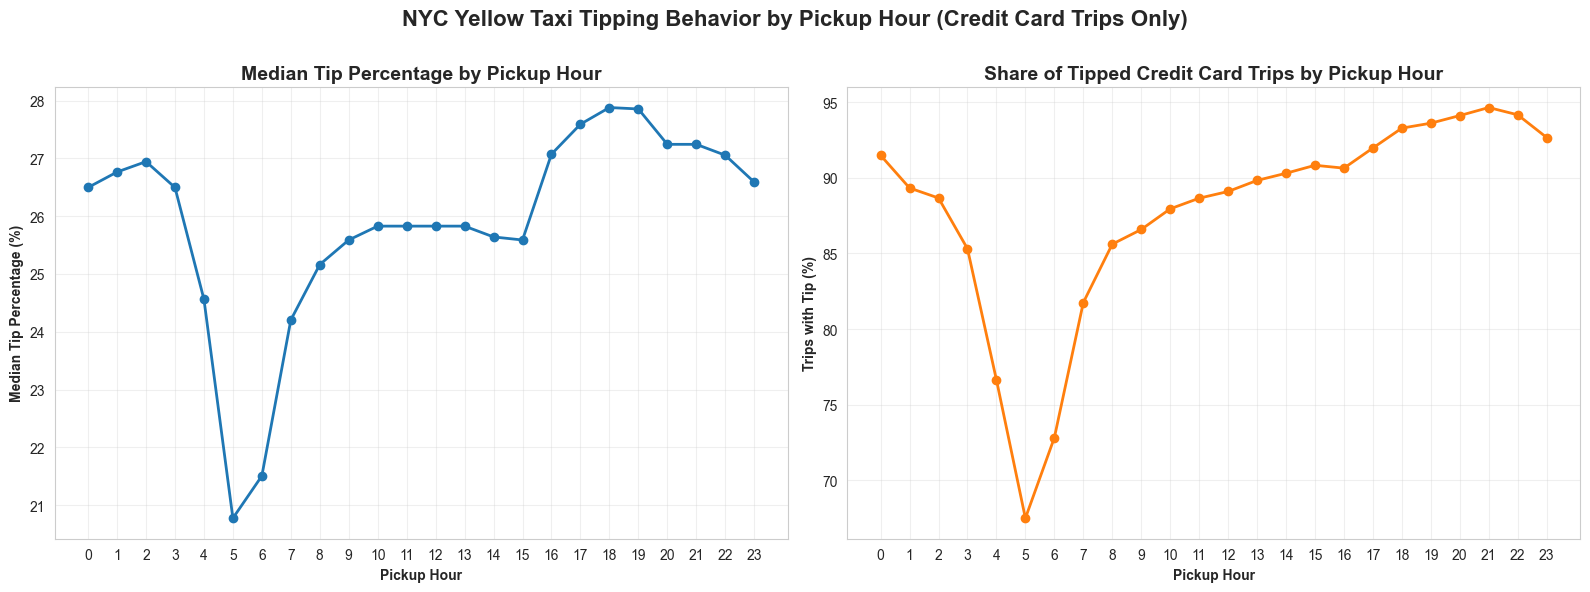

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# Median tip percentage
axes[0].plot(
    hourly_tipping["pickup_hour"],
    hourly_tipping["median_tip_percentage"],
    marker="o",
    linewidth=2,
    color="#1f77b4"
)

axes[0].set_title(
    "Median Tip Percentage by Pickup Hour",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("Pickup Hour", fontweight="bold")
axes[0].set_ylabel("Median Tip Percentage (%)", fontweight="bold")
axes[0].set_xticks(range(24))
axes[0].grid(True, alpha=0.3)


# Share of trips with a recorded tip
axes[1].plot(
    hourly_tipping["pickup_hour"],
    hourly_tipping["tipped_trip_pct"],
    marker="o",
    linewidth=2,
    color="#ff7f0e"
)

axes[1].set_title(
    "Share of Tipped Credit Card Trips by Pickup Hour",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("Pickup Hour", fontweight="bold")
axes[1].set_ylabel("Trips with Tip (%)", fontweight="bold")
axes[1].set_xticks(range(24))
axes[1].grid(True, alpha=0.3)


fig.suptitle(
    "NYC Yellow Taxi Tipping Behavior by Pickup Hour (Credit Card Trips Only)",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
fig.subplots_adjust(top=0.85)

filepath = os.path.join(
    "img",
    "NYC_Yellow_Taxi_Tipping_Behavior_by_Pickup_Hour.png"
)

plt.savefig(
    filepath,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

### Insight: Tipping Behavior by Pickup Hour for Credit Card Trips

- Tipping behavior changes noticeably throughout the day. Both the median tip percentage and the share of trips with a recorded tip are lowest during the early-morning period, especially around **4 AM to 6 AM**.

- The lowest point occurs around **5 AM**, where the median tip percentage falls to roughly **21%** and only around **68%** of credit-card trips include a recorded tip. This may reflect a different trip mix during early morning hours, such as airport travel, shorter trips, or late-night passengers.

- Tipping recovers quickly after **7 AM** and remains relatively stable at around **25%–26%** throughout most daytime hours.

- The strongest tipping behavior appears during the evening, especially around **5 PM to 9 PM**. Median tip percentage reaches almost **28%**, while more than **93%** of credit-card trips include a tip.

- Overall, pickup hour is associated not only with taxi demand and speed, but also with passenger payment behavior. However, this result applies only to credit-card trips because cash tips are not reliably captured in the dataset.

## Chapter 3 Summary: Key Findings

- **Taxi demand follows a strong daily pattern.** Trip volume is lowest during the early morning, especially around **4 AM**, then rises steadily throughout the day and peaks around **6 PM**.

- **Demand is highest toward the end of the week.** Saturday records the highest number of trips, while Sunday and Monday have the lowest demand. This indicates that taxi activity is influenced by both workday and weekend travel patterns.

- **Manhattan is the core of Yellow Taxi activity.** More than **3.1 million trips** start and end in Manhattan, while the most common borough route is overwhelmingly **Manhattan → Manhattan**.

- **Most trips are short, local journeys.** Around **85%** of trips remain within the same borough, with a median distance of **1.56 miles** and a median total amount of **$21.40**.

- **Interborough trips are less frequent but much more valuable.** Although they represent only around **15%** of all trips, their median distance reaches **9.33 miles** and their median total amount is approximately **$55.00**.

- **Traffic conditions have a clear impact on trip efficiency.** Taxi speeds are highest during the early-morning free-flow period and lowest during daytime congestion, particularly from late morning to early evening.

- **Credit card is the dominant payment method**, accounting for around **61%** of trips. Flex Fare trips are the second-largest category and show the highest median total amount, suggesting a different pricing structure or higher-value trip profile.

- **Tipping behavior also changes by time of day.** For credit-card trips, both median tip percentage and the share of tipped trips are lowest around **4 AM–6 AM** and strongest during the evening period.

Overall, pickup time, pickup and dropoff location, trip scope, and payment behavior all show meaningful relationships with taxi demand, trip duration, speed, and total trip value. These findings provide a strong foundation for the machine learning stage, especially for predicting trip duration.